# Pipeline Completo: Classificação de Ataques DoS em MQTT

## Objetivos
1. Limpeza de dados - remover features inúteis do Wireshark
2. Engenharia de features - criar `connect_gap` e `publish_gap`
3. Baseline com modelos de baixo custo sem seleção de features
4. Seleção de features com múltiplos seletores
5. Ensemble (Soft Voting + Averaging)
6. Otimização de hiperparâmetros com Optuna
7. Análise detalhada de resultados

In [1]:
# Configuracao inicial
import json
from pathlib import Path
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')
# Machine Learning
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
# Metricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    )
# Otimizacao
import optuna
from optuna.samplers import TPESampler
# Configuracao de exibicao
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
timing_records = []
TIMING_DEFAULTS = {
    'stage': None,
    'seletor': None,
    'modelo': None,
    'status': 'success',
    'error_message': None,
    'n_features': np.nan,
    'n_trials': np.nan,
    'n_cv_folds': np.nan,
    'tempo_fit_sec': np.nan,
    'tempo_predict_sec': np.nan,
    'tempo_proba_sec': np.nan,
    'tempo_joblib_dump_sec': np.nan,
    'tempo_otimizacao_sec': np.nan,
    'tempo_total_sec': np.nan,
    'experiment_timestamp': None,
}
def append_timing_record(stage, **payload):
    record = TIMING_DEFAULTS.copy()
    record['stage'] = stage
    record['experiment_timestamp'] = pd.Timestamp.now().isoformat()
    record.update(payload)
    timing_records.append(record)
    return record
print("OK: bibliotecas importadas com sucesso")


OK: bibliotecas importadas com sucesso


## 1. Carregamento e Exploração Inicial dos Dados

In [2]:
# Carregar dados
dos_path = Path('../data/raw/MQTT Under Attack Dataset/DoS.csv')
df = pd.read_csv(dos_path)
print(f"Dataset shape: {df.shape}")
print(f"\nColunas ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nTipos de tráfego:")
print(df['type'].value_counts())


Dataset shape: (94625, 67)

Colunas (67):
['frame.time_delta', 'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 'frame.time_relative', 'ip.src', 'ip.dst', 'tcp.srcport', 'tcp.dstport', 'eth.src', 'eth.dst', 'frame.cap_len', 'frame.coloring_rule.name', 'frame.coloring_rule.string', 'frame.comment', 'frame.comment.expert', 'frame.encap_type', 'frame.file_off', 'frame.ignored', 'frame.incomplete', 'frame.interface_id', 'frame.interface_name', 'frame.len', 'frame.link_nr', 'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift', 'mqtt.clientid', 'mqtt.clientid_len', 'mqtt.conack.flags', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.conflags', 'mqtt.dupflag', 'mqtt.hdrflags', 'mqtt.kalive', 'mqtt.len', 'mqtt.msg', 'mqtt.msgid', 'mqtt.msgtype', 'mqtt.passwd', '

In [3]:
# Análise de valores nulos e tipos de dados
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_analysis = pd.DataFrame({
    'coluna': df.columns,
    'nulos': null_counts.values,
    'percent_nulos': null_percent.values,
    'dtype': df.dtypes.values
})
print("Colunas com valores nulos:")
print(null_analysis[null_analysis['nulos'] > 0].sort_values('percent_nulos', ascending=False))


Colunas com valores nulos:
                        coluna  nulos  percent_nulos    dtype
3           frame.time_invalid  94625     100.000000  float64
15        frame.comment.expert  94625     100.000000  float64
14               frame.comment  94625     100.000000  float64
13  frame.coloring_rule.string  94625     100.000000  float64
12    frame.coloring_rule.name  94625     100.000000  float64
23               frame.link_nr  94625     100.000000  float64
25              frame.md5_hash  94625     100.000000  float64
20          frame.interface_id  94625     100.000000  float64
21        frame.interface_name  94625     100.000000  float64
17              frame.file_off  94625     100.000000  float64
19            frame.incomplete  94625     100.000000  float64
60           mqtt.username_len  94625     100.000000  float64
49                 mqtt.passwd  94625     100.000000  float64
50             mqtt.passwd_len  94625     100.000000  float64
63            mqtt.willmsg_len  94625     1

## 2. Limpeza de Dados

Remover features inúteis do Wireshark que não têm significância para classificação.

In [4]:
# Definir colunas a serem removidas (features inúteis do Wireshark)
columns_to_remove = [
    # Metadados do frame
    'frame.time_delta_displayed',
    'frame.time_epoch',
    'frame.time_invalid',
    'frame.time_relative',
    'frame.coloring_rule.name',
    'frame.coloring_rule.string',
    'frame.comment',
    'frame.comment.expert',
    'frame.encap_type',
    'frame.file_off',
    'frame.ignored',
    'frame.incomplete',
    'frame.interface_id',
    'frame.interface_name',
    'frame.link_nr',
    'frame.marked',
    'frame.md5_hash',
    'frame.number',
    'frame.offset_shift',
    
    # IPs e MACs (identificadores únicos, não padrões)
    'ip.src', 'ip.dst',
    'eth.src', 'eth.dst',
    
    # Portas TCP (podem ser úteis mas vamos remover por enquanto)
    'tcp.srcport', 'tcp.dstport',
    
    # Campos vazios ou quase vazios
    'mqtt.clientid',
    'mqtt.conack.flags',
    'mqtt.conflags',
    'mqtt.dupflag',
    'mqtt.hdrflags',
    'mqtt.msg',
    'mqtt.msgid',
    'mqtt.passwd',
    'mqtt.passwd_len',
    'mqtt.proto_len',
    'mqtt.protoname',
    'mqtt.sub.qos',
    'mqtt.suback.qos',
    'mqtt.topic',
    'mqtt.username',
    'mqtt.username_len',
    'mqtt.ver',
    'mqtt.willmsg',
    'mqtt.willmsg_len',
    'mqtt.willtopic',
    'mqtt.willtopic_len'
]
# Remover colunas que existem no dataset
existing_cols_to_remove = [col for col in columns_to_remove if col in df.columns]
df_clean = df.drop(columns=existing_cols_to_remove)
print(f"Colunas removidas: {len(existing_cols_to_remove)}")
print(f"Colunas restantes: {len(df_clean.columns)}")
print(f"\nColunas restantes:")
print(df_clean.columns.tolist())


Colunas removidas: 46
Colunas restantes: 21

Colunas restantes:
['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.retain', 'mqtt.topic_len', 'type']


In [5]:
# Verificar colunas restantes e seus tipos
print("Resumo das colunas após limpeza:")
for col in df_clean.columns:
    unique_vals = df_clean[col].nunique()
    null_count = df_clean[col].isnull().sum()
    print(f"{col}: {df_clean[col].dtype}, únicos={unique_vals}, nulos={null_count}")


Resumo das colunas após limpeza:
frame.time_delta: float64, únicos=9884, nulos=0
frame.cap_len: int64, únicos=1292, nulos=0
frame.len: int64, únicos=1292, nulos=0
mqtt.clientid_len: float64, únicos=6, nulos=94302
mqtt.conack.flags.reserved: float64, únicos=2, nulos=93855
mqtt.conack.flags.sp: float64, únicos=2, nulos=93855
mqtt.conack.val: float64, únicos=12, nulos=93855
mqtt.conflag.cleansess: float64, únicos=1, nulos=94302
mqtt.conflag.passwd: float64, únicos=1, nulos=94302
mqtt.conflag.qos: float64, únicos=1, nulos=94302
mqtt.conflag.reserved: float64, únicos=1, nulos=94302
mqtt.conflag.retain: float64, únicos=1, nulos=94302
mqtt.conflag.uname: float64, únicos=1, nulos=94302
mqtt.conflag.willflag: float64, únicos=1, nulos=94302
mqtt.kalive: float64, únicos=2, nulos=94302
mqtt.len: float64, únicos=76, nulos=55090
mqtt.msgtype: float64, únicos=12, nulos=55090
mqtt.qos: float64, únicos=4, nulos=56161
mqtt.retain: float64, únicos=2, nulos=56161
mqtt.topic_len: float64, únicos=60, nulos=

## 3. Engenharia de Features

Criar duas features importantes:
- `connect_gap`: intervalo entre mensagens CONNECT
- `publish_gap`: intervalo entre mensagens PUBLISH

In [6]:
def calculate_gaps(df, time_col='frame.time_epoch', msgtype_col='mqtt.msgtype'):
    """
    Calcula gaps entre mensagens CONNECT (tipo 1) e PUBLISH (tipo 3)
    """
    df = df.copy()
    df['connect_gap'] = 0.0
    df['publish_gap'] = 0.0
    
    # Precisamos do time_epoch para calcular gaps
    
    return df
# Recarregar com timestamp
df_full = pd.read_csv(dos_path)
# Manter apenas colunas relevantes para cálculo
time_features = ['frame.time_epoch', 'mqtt.msgtype', 'type']
time_features = [col for col in time_features if col in df_full.columns]
print("Calculando gaps entre mensagens...")
print(f"MQTT msgtype values: {df_full['mqtt.msgtype'].unique() if 'mqtt.msgtype' in df_full.columns else 'N/A'}")


Calculando gaps entre mensagens...
MQTT msgtype values: [nan 12. 13.  3.  1.  2.  0.  6.  4. 14.  7.  8.  9.]


In [7]:
# Calcular publish_gap - intervalo entre mensagens PUBLISH (tipo 3)
# e connect_gap - intervalo entre mensagens CONNECT (tipo 1)

if 'frame.time_epoch' in df_full.columns:
    df_full = df_full.sort_values('frame.time_epoch').reset_index(drop=True)
    
    # Inicializar gaps
    df_full['publish_gap'] = 0.0
    df_full['connect_gap'] = 0.0
    
    # Para cada tipo de tráfego, calcular gaps separadamente
    for traffic_type in df_full['type'].unique():
        mask = df_full['type'] == traffic_type
        subset = df_full[mask].copy()
        
        if len(subset) > 1:
            timestamps = subset['frame.time_epoch'].values
            msgtypes = subset['mqtt.msgtype'].fillna(0).values
            
            # Calcular publish gaps (msgtype == 3)
            publish_indices = np.where(msgtypes == 3)[0]
            if len(publish_indices) > 1:
                publish_times = timestamps[publish_indices]
                publish_gaps = np.diff(publish_times)
                # Preencher gaps (o primeiro publish fica com 0)
                for i, idx in enumerate(publish_indices[1:], 1):
                    actual_idx = subset.index[idx]
                    df_full.loc[actual_idx, 'publish_gap'] = publish_gaps[i-1]
            
            # Calcular connect gaps (msgtype == 1)
            connect_indices = np.where(msgtypes == 1)[0]
            if len(connect_indices) > 1:
                connect_times = timestamps[connect_indices]
                connect_gaps = np.diff(connect_times)
                for i, idx in enumerate(connect_indices[1:], 1):
                    actual_idx = subset.index[idx]
                    df_full.loc[actual_idx, 'connect_gap'] = connect_gaps[i-1]
    
    print(f"✅ Gaps calculados!")
    print(f"Publish gap não-zero: {(df_full['publish_gap'] != 0).sum()}")
    print(f"Connect gap não-zero: {(df_full['connect_gap'] != 0).sum()}")
else:
    print("❌ Timestamp não encontrado")


✅ Gaps calculados!
Publish gap não-zero: 6150
Connect gap não-zero: 321


In [8]:
# Adicionar as features de gap ao dataset limpo
if 'publish_gap' in df_full.columns and 'connect_gap' in df_full.columns:
    df_clean['publish_gap'] = df_full['publish_gap'].values
    df_clean['connect_gap'] = df_full['connect_gap'].values
print(f"Features adicionadas: {['publish_gap', 'connect_gap']}")
print(f"\nEstatísticas dos gaps:")
print(df_clean[['publish_gap', 'connect_gap']].describe())


Features adicionadas: ['publish_gap', 'connect_gap']

Estatísticas dos gaps:
        publish_gap   connect_gap
count  94625.000000  94625.000000
mean       0.015476      0.008903
std        1.287471      1.457297
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max      248.223048    268.935206


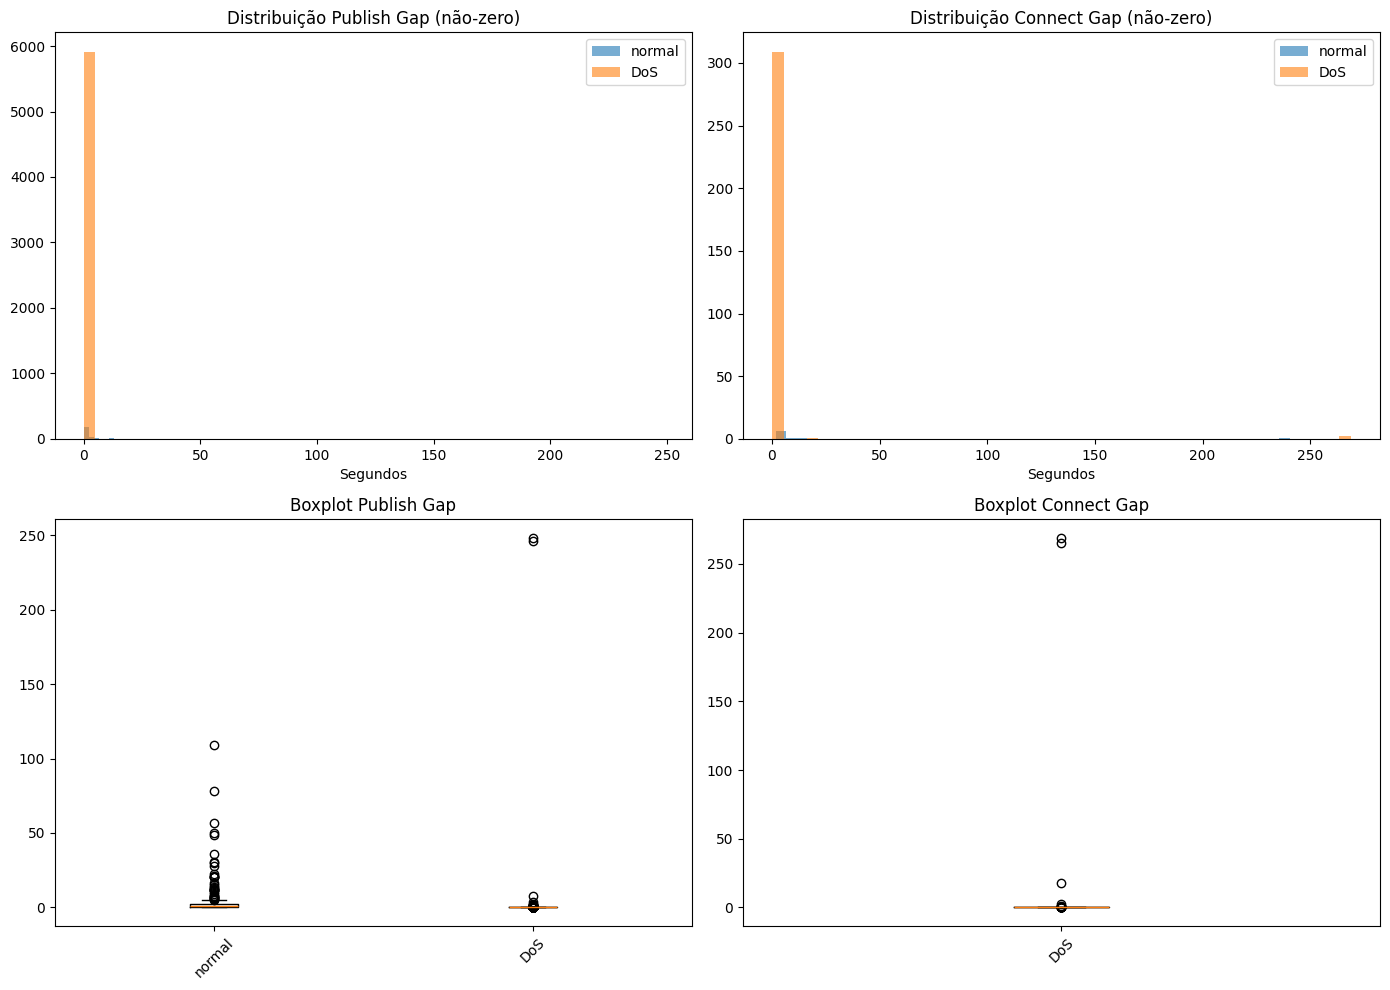

✅ Gráfico salvo em reports_refactored/gap_features_distribution.png


In [9]:
# Visualizar distribuição dos gaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Publish gap por tipo
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['publish_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 0:
        axes[0, 0].hist(data_nonzero, bins=50, alpha=0.6, label=traffic_type)
axes[0, 0].set_title('Distribuição Publish Gap (não-zero)')
axes[0, 0].set_xlabel('Segundos')
axes[0, 0].legend()
# Connect gap por tipo
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['connect_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 0:
        axes[0, 1].hist(data_nonzero, bins=50, alpha=0.6, label=traffic_type)
axes[0, 1].set_title('Distribuição Connect Gap (não-zero)')
axes[0, 1].set_xlabel('Segundos')
axes[0, 1].legend()
# Boxplot publish gap
data_for_box = []
labels_for_box = []
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['publish_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 10:
        data_for_box.append(data_nonzero)
        labels_for_box.append(traffic_type)
if data_for_box:
    axes[1, 0].boxplot(data_for_box, labels=labels_for_box)
    axes[1, 0].set_title('Boxplot Publish Gap')
    axes[1, 0].tick_params(axis='x', rotation=45)
# Boxplot connect gap
data_for_box = []
labels_for_box = []
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['connect_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 10:
        data_for_box.append(data_nonzero)
        labels_for_box.append(traffic_type)
if data_for_box:
    axes[1, 1].boxplot(data_for_box, labels=labels_for_box)
    axes[1, 1].set_title('Boxplot Connect Gap')
    axes[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/reports_ensemble_v2/gap_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports_refactored/gap_features_distribution.png")


## 4. Preparação dos Dados para ML

In [10]:
# Separar features e target
X = df_clean.drop('type', axis=1)
y = df_clean['type']
print(f"Features: {X.shape[1]}")
print(f"Amostras: {X.shape[0]}")
print(f"Classes: {y.unique()}")
# Verificar valores nulos nas features
null_features = X.isnull().sum()
null_features = null_features[null_features > 0]
print(f"\nFeatures com nulos: {len(null_features)}")
if len(null_features) > 0:
    print(null_features)


Features: 22
Amostras: 94625
Classes: <StringArray>
['normal', 'DoS']
Length: 2, dtype: str

Features com nulos: 17
mqtt.clientid_len             94302
mqtt.conack.flags.reserved    93855
mqtt.conack.flags.sp          93855
mqtt.conack.val               93855
mqtt.conflag.cleansess        94302
mqtt.conflag.passwd           94302
mqtt.conflag.qos              94302
mqtt.conflag.reserved         94302
mqtt.conflag.retain           94302
mqtt.conflag.uname            94302
mqtt.conflag.willflag         94302
mqtt.kalive                   94302
mqtt.len                      55090
mqtt.msgtype                  55090
mqtt.qos                      56161
mqtt.retain                   56161
mqtt.topic_len                56157
dtype: int64


In [11]:
from sklearn.impute import SimpleImputer

# MANTENDO NULOS PARA IMPUTACAO APOS O SPLIT
# X = X.fillna(0) # REMOVIDO PARA EVITAR LEAKAGE

# Dividir em treino e teste (com nulos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino antes da imputacao nulos: {X_train.isnull().sum().sum()}")
print(f"Teste antes da imputacao nulos: {X_test.isnull().sum().sum()}")

# Imputar valores ausentes APOS o split (Cenario 1 - Constant = 0)
imputer = SimpleImputer(strategy='constant', fill_value=0)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print(f"Treino apos imputacao nulos: {X_train.isnull().sum().sum()}")
print(f"Teste apos imputacao nulos: {X_test.isnull().sum().sum()}")

print(f"\nTreino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")


Treino antes da imputacao nulos: 1127118
Teste antes da imputacao nulos: 281824
Treino apos imputacao nulos: 0
Teste apos imputacao nulos: 0

Treino: 75700 amostras
Teste: 18925 amostras

Distribuição no treino:
type
normal    39289
DoS       36411
Name: count, dtype: int64

Distribuição no teste:
type
normal    9822
DoS       9103
Name: count, dtype: int64


In [12]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Converter para DataFrame para manter nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
print("✅ Dados normalizados")


✅ Dados normalizados


## 5. Baseline - Modelos de Baixo Custo sem Seleção de Features

Modelos utilizados:
- LDA (Linear Discriminant Analysis)
- QDA (Quadratic Discriminant Analysis)
- Gaussian Naive Bayes
- Decision Tree
- Random Forest
- Gradient Boosted Trees

In [13]:
# Definir modelos baseline (somente os 6 solicitados)
baseline_models = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'GaussianNB': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=10),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE, max_depth=5),
}
MODELS_REQUIRING_SCALING = {'LDA', 'QDA'}
def evaluate_model(model_name, model, X_train_raw, X_test_raw, X_train_scaled, X_test_scaled, y_train, y_test):
    """Avalia modelo sempre com as metricas obrigatorias, tempos internos e matriz de confusao."""
    if model_name in MODELS_REQUIRING_SCALING:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train_raw, X_test_raw
    fit_start = time.perf_counter()
    model.fit(Xtr, y_train)
    tempo_fit_sec = time.perf_counter() - fit_start
    predict_start = time.perf_counter()
    y_pred = model.predict(Xte)
    tempo_predict_sec = time.perf_counter() - predict_start
    proba_start = time.perf_counter()
    y_prob = model.predict_proba(Xte)
    tempo_proba_sec = time.perf_counter() - proba_start
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    fp_per_class = cm.sum(axis=0) - np.diag(cm)
    fn_per_class = cm.sum(axis=1) - np.diag(cm)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'log_loss': log_loss(y_test, y_prob, labels=sorted(y_test.unique())),
    }
    tempo_total_sec = tempo_fit_sec + tempo_predict_sec + tempo_proba_sec
    return {
        'metrics': metrics,
        'predictions': y_pred,
        'probabilities': y_prob,
        'confusion_matrix': cm,
        'fp_per_class': fp_per_class.tolist(),
        'fn_per_class': fn_per_class.tolist(),
        'tempo_fit_sec': tempo_fit_sec,
        'tempo_predict_sec': tempo_predict_sec,
        'tempo_proba_sec': tempo_proba_sec,
        'tempo_total_sec': tempo_total_sec,
    }
print("Avaliador padronizado configurado")


Avaliador padronizado configurado


In [14]:
# Executar avaliacao dos modelos baseline
baseline_results = {}
print("Avaliando modelos baseline...")
for name, model in baseline_models.items():
    print(f"\nTreinando {name}...")
    result = evaluate_model(
        model_name=name,
        model=model.__class__(**model.get_params()),
        X_train_raw=X_train,
        X_test_raw=X_test,
        X_train_scaled=X_train_scaled,
        X_test_scaled=X_test_scaled,
        y_train=y_train,
        y_test=y_test,
    )
    baseline_results[name] = result
    append_timing_record(
        'baseline',
        modelo=name,
        n_features=X_train.shape[1],
        tempo_fit_sec=result['tempo_fit_sec'],
        tempo_predict_sec=result['tempo_predict_sec'],
        tempo_proba_sec=result['tempo_proba_sec'],
        tempo_total_sec=result['tempo_total_sec'],
    )
    metrics = result['metrics']
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  F1 Score:  {metrics['f1']:.4f}")
    print(f"  Log Loss:  {metrics['log_loss']:.4f}")
    print(f"  FP por classe: {result['fp_per_class']}")
    print(f"  FN por classe: {result['fn_per_class']}")


Avaliando modelos baseline...

Treinando LDA...
  Accuracy:  0.9239
  Precision: 0.9326
  F1 Score:  0.9232
  Log Loss:  0.3766
  FP por classe: [37, 1404]
  FN por classe: [1404, 37]

Treinando QDA...
  Accuracy:  0.9231
  Precision: 0.9315
  F1 Score:  0.9225
  Log Loss:  0.9014
  FP por classe: [53, 1403]
  FN por classe: [1403, 53]

Treinando GaussianNB...
  Accuracy:  0.9205
  Precision: 0.9282
  F1 Score:  0.9199
  Log Loss:  2.7174
  FP por classe: [105, 1400]
  FN por classe: [1400, 105]

Treinando DecisionTree...
  Accuracy:  0.9743
  Precision: 0.9746
  F1 Score:  0.9743
  Log Loss:  0.1359
  FP por classe: [129, 357]
  FN por classe: [357, 129]

Treinando RandomForest...
  Accuracy:  0.9741
  Precision: 0.9747
  F1 Score:  0.9740
  Log Loss:  0.0724
  FP por classe: [69, 422]
  FN por classe: [422, 69]

Treinando GradientBoosting...
  Accuracy:  0.9751
  Precision: 0.9754
  F1 Score:  0.9750
  Log Loss:  0.0736
  FP por classe: [97, 375]
  FN por classe: [375, 97]


In [15]:
# Criar DataFrame com resultados baseline
baseline_df = pd.DataFrame([
    {
        'Modelo': name,
        'accuracy': result['metrics']['accuracy'],
        'precision': result['metrics']['precision'],
        'f1': result['metrics']['f1'],
        'log_loss': result['metrics']['log_loss'],
    }
    for name, result in baseline_results.items()
])
baseline_df = baseline_df.sort_values('f1', ascending=False)
print("\nResultados Baseline (ordenados por F1):")
print(baseline_df.to_string(index=False))
baseline_timing_df = pd.DataFrame([record for record in timing_records if record['stage'] == 'baseline'])
baseline_timing_df.to_csv('../reports/reports_ensemble_v2/baseline_timing_results.csv', index=False)
# Salvar resultados
baseline_df.to_csv('../reports/reports_ensemble_v2/baseline_results.csv', index=False)
print("\nOK: resultados salvos em reports_refactored/baseline_results.csv")
print("OK: tempos salvos em reports_refactored/baseline_timing_results.csv")



Resultados Baseline (ordenados por F1):
          Modelo  accuracy  precision       f1  log_loss
GradientBoosting  0.975059   0.975443 0.975040  0.073571
    DecisionTree  0.974320   0.974573 0.974304  0.135895
    RandomForest  0.974055   0.974682 0.974028  0.072422
             LDA  0.923857   0.932576 0.923244  0.376601
             QDA  0.923065   0.931535 0.922457  0.901391
      GaussianNB  0.920476   0.928173 0.919890  2.717418

OK: resultados salvos em reports_refactored/baseline_results.csv
OK: tempos salvos em reports_refactored/baseline_timing_results.csv


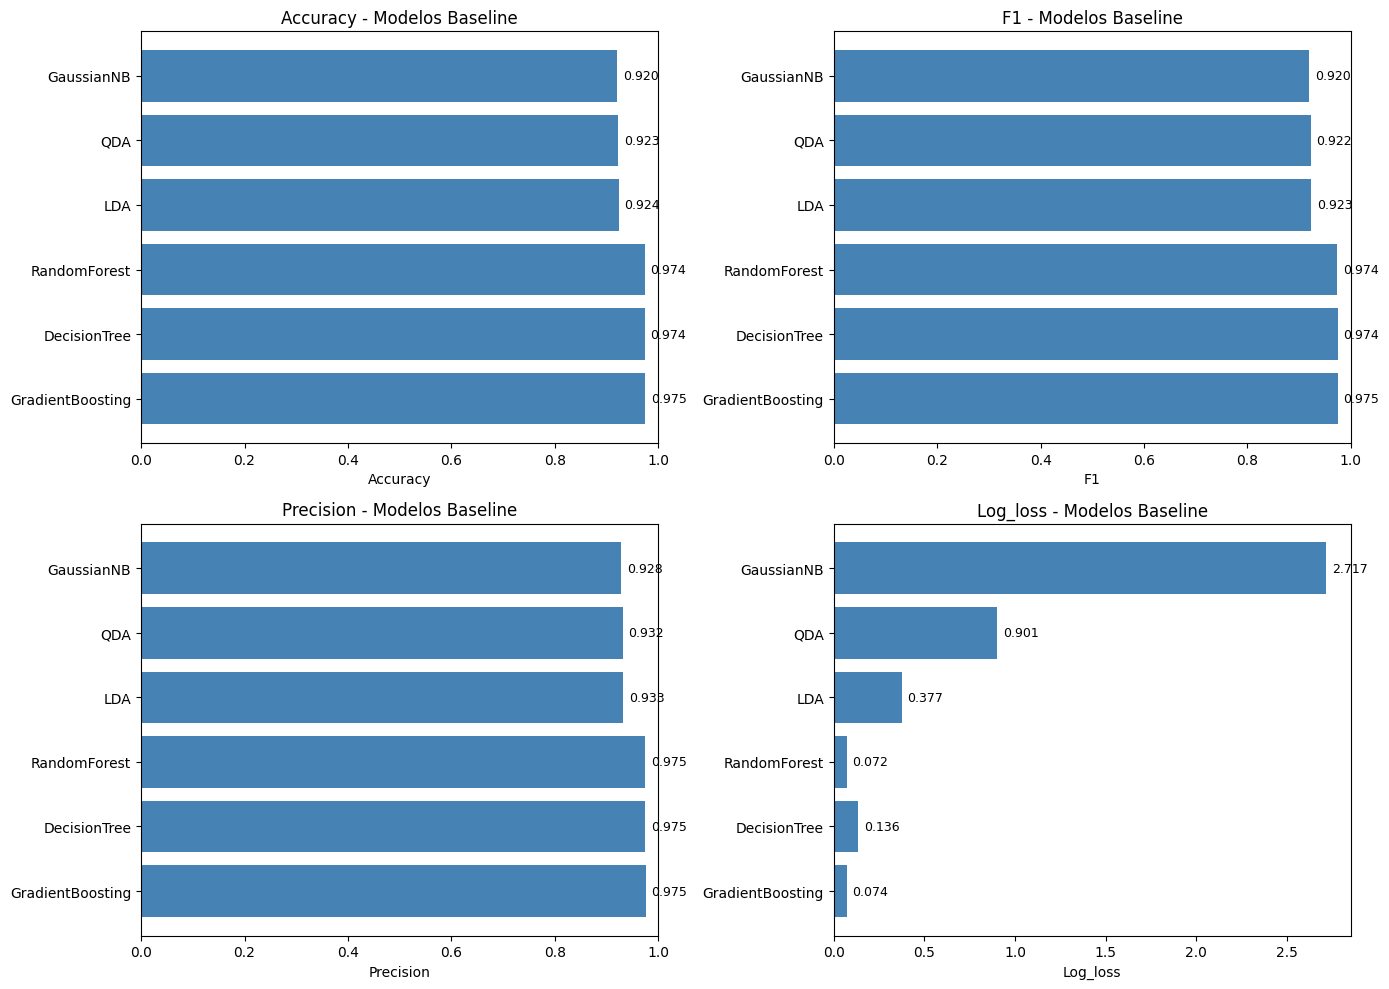

In [16]:
# Visualizar comparacao dos modelos baseline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['accuracy', 'f1', 'precision', 'log_loss']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(baseline_df['Modelo'], baseline_df[metric], color='steelblue')
    ax.set_xlabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()} - Modelos Baseline')
    if metric != 'log_loss':
        ax.set_xlim(0, 1)
    labels = [f'{val:.3f}' if np.isfinite(val) else 'N/A' for val in baseline_df[metric].values]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9)
plt.tight_layout()
plt.savefig('../reports/reports_ensemble_v2/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Seleção de Features

Usar os seguintes seletores:
- Low Variance
- Pearson Correlation
- Fisher Score
- mRMR
- LassoCV (L1)
- LinearSVC (L1)
- Extra Trees (importância de features)

In [17]:
# Implementar seletores de features
from sklearn.feature_selection import VarianceThreshold
def get_selected_features(X, y, selector_name, n_features=15):
    feature_names = X.columns.tolist()
    
    if selector_name == 'LowVariance':
        # Remover features com baixa variância
        selector = VarianceThreshold(threshold=0.01)
        X_selected = selector.fit_transform(X)
        selected_mask = selector.get_support()
        selected = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]
        return selected[:n_features] if len(selected) > n_features else selected
    
    elif selector_name == 'Pearson':
        # Correlação de Pearson (F-test)
        selector = SelectKBest(score_func=f_classif, k=n_features)
        selector.fit(X, y)
        scores = selector.scores_
        # Pegar top n_features
        top_indices = np.argsort(scores)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'Fisher':
        # Fisher Score (similar a f_classif)
        selector = SelectKBest(score_func=f_classif, k=n_features)
        selector.fit(X, y)
        scores = selector.scores_
        top_indices = np.argsort(scores)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'mRMR':
        # Implementação simplificada: usar mutual_info como aproximação
        selector = SelectKBest(score_func=mutual_info_classif, k=n_features)
        selector.fit(X, y)
        scores = selector.scores_
        top_indices = np.argsort(scores)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'LassoCV':
        # L1 regularization
        lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=2000)
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        lasso.fit(X, y_encoded)
        coef_importance = np.abs(lasso.coef_)
        top_indices = np.argsort(coef_importance)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'LinearSVC_L1':
        # LinearSVC com L1
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        lsvc = LinearSVC(C=0.1, penalty='l1', dual=False, max_iter=5000, random_state=RANDOM_STATE)
        lsvc.fit(X, y_encoded)
        coef_importance = np.abs(lsvc.coef_).flatten() if len(lsvc.coef_.shape) > 1 else np.abs(lsvc.coef_)
        top_indices = np.argsort(coef_importance)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'ExtraTrees':
        # Extra Trees Classifier
        et = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=10)
        et.fit(X, y)
        importances = et.feature_importances_
        top_indices = np.argsort(importances)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    else:
        return feature_names[:n_features]
# Executar seleção de features
selectors = ['LowVariance', 'Pearson', 'Fisher', 'mRMR', 'LassoCV', 'LinearSVC_L1', 'ExtraTrees']
N_FEATURES = 15
selected_features_dict = {}
for selector in selectors:
    print(f"Executando seletor: {selector}...")
    try:
        features = get_selected_features(X_train, y_train, selector, N_FEATURES)
        selected_features_dict[selector] = features
        print(f"  ✓ Selecionadas {len(features)} features")
    except Exception as e:
        print(f"  ✗ Erro: {e}")
        selected_features_dict[selector] = X.columns.tolist()[:N_FEATURES]


Executando seletor: LowVariance...
  ✓ Selecionadas 12 features
Executando seletor: Pearson...
  ✓ Selecionadas 15 features
Executando seletor: Fisher...
  ✓ Selecionadas 15 features
Executando seletor: mRMR...
  ✓ Selecionadas 15 features
Executando seletor: LassoCV...
  ✓ Selecionadas 15 features
Executando seletor: LinearSVC_L1...
  ✓ Selecionadas 15 features
Executando seletor: ExtraTrees...
  ✓ Selecionadas 15 features


In [18]:
# Mostrar features selecionadas por cada método
for selector, features in selected_features_dict.items():
    print(f"\n{selector} ({len(features)} features):")
    print(f"  {features}")
# Salvar features selecionadas
import json
with open('../reports/reports_ensemble_v2/selected_features.json', 'w') as f:
    json.dump(selected_features_dict, f, indent=2)
print("\n✅ Features selecionadas salvas em reports_refactored/selected_features.json")



LowVariance (12 features):
  ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.val', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.topic_len', 'publish_gap', 'connect_gap']

Pearson (15 features):
  ['mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.len', 'mqtt.msgtype', 'frame.len', 'frame.cap_len', 'mqtt.topic_len', 'mqtt.qos', 'mqtt.conack.flags.reserved', 'mqtt.retain', 'mqtt.conack.val']

Fisher (15 features):
  ['mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.len', 'mqtt.msgtype', 'frame.len', 'frame.cap_len', 'mqtt.topic_len', 'mqtt.qos', 'mqtt.conack.flags.reserved', 'mqtt.retain', 'mqtt.conack.val']

mRMR (15 features):
  ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'publish_gap', 'mqtt.co

In [19]:
# Criar matriz de consenso (quais features foram selecionadas por quantos métodos)
all_features = set()
for features in selected_features_dict.values():
    all_features.update(features)
consensus_df = pd.DataFrame(index=sorted(all_features), columns=selectors)
for selector, features in selected_features_dict.items():
    consensus_df[selector] = [feat in features for feat in consensus_df.index]
# Contar em quantos métodos cada feature apareceu
consensus_df['count'] = consensus_df.sum(axis=1)
consensus_df = consensus_df.sort_values('count', ascending=False)
print("Features por consenso (ordenadas por frequência de seleção):")
print(consensus_df.head(20))
# Features consenso (mais da metade dos seletores)
consensus_threshold = len(selectors) // 2 + 1
consensus_features = consensus_df[consensus_df['count'] >= consensus_threshold].index.tolist()
print(f"\nFeatures de consenso (aparecem em >= {consensus_threshold} seletores): {len(consensus_features)}")
print(consensus_features)


Features por consenso (ordenadas por frequência de seleção):
                            LowVariance  Pearson  Fisher   mRMR  LassoCV  \
frame.cap_len                      True     True    True   True     True   
frame.len                          True     True    True   True     True   
mqtt.topic_len                     True     True    True   True     True   
mqtt.msgtype                       True     True    True   True     True   
mqtt.len                           True     True    True   True     True   
mqtt.qos                           True     True    True  False     True   
mqtt.retain                       False     True    True   True     True   
mqtt.conflag.uname                False     True    True   True     True   
mqtt.kalive                        True    False   False   True     True   
connect_gap                        True    False   False   True     True   
publish_gap                        True    False   False   True     True   
mqtt.conack.val            

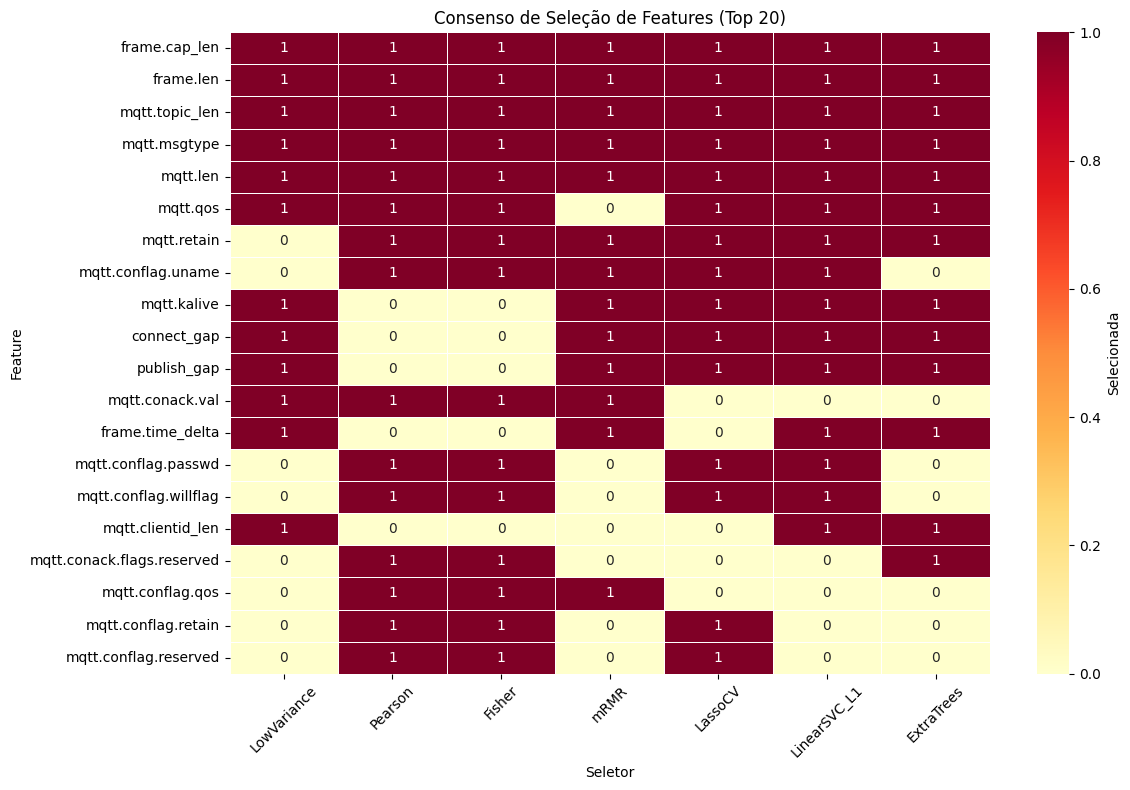

In [20]:
# Visualizar consenso de features
plt.figure(figsize=(12, 8))
top_features = consensus_df.head(20)
# Criar heatmap
heatmap_data = top_features[selectors].astype(int)
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Selecionada'}, 
            linewidths=0.5, annot=True, fmt='d')
plt.title('Consenso de Seleção de Features (Top 20)')
plt.xlabel('Seletor')
plt.ylabel('Feature')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/reports_ensemble_v2/feature_consensus_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Treinamento com Seleção de Features

In [21]:
# Avaliar modelos com cada conjunto de features selecionadas utilziando os 6 modelos em todos os seletores 
models_for_selection = list(baseline_models.keys())
print(f"Modelos avaliados com selecao de features: {models_for_selection}")
selection_results = []
confusion_matrices_by_selector = {}
best_confusion_matrix_by_selector = {}
for selector_name, features in selected_features_dict.items():
    print(f"\n{'=' * 70}")
    print(f"Seletor: {selector_name} ({len(features)} features)")
    print(f"{'=' * 70}")
    X_train_sel = X_train[features]
    X_test_sel = X_test[features]
    X_train_sel_scaled = X_train_scaled[features]
    X_test_sel_scaled = X_test_scaled[features]
    confusion_matrices_by_selector[selector_name] = {}
    selector_rows = []
    selector_start = time.perf_counter()
    for model_name in models_for_selection:
        model = baseline_models[model_name]
        result = evaluate_model(
            model_name=model_name,
            model=model.__class__(**model.get_params()),
            X_train_raw=X_train_sel,
            X_test_raw=X_test_sel,
            X_train_scaled=X_train_sel_scaled,
            X_test_scaled=X_test_sel_scaled,
            y_train=y_train,
            y_test=y_test,
        )
        confusion_matrices_by_selector[selector_name][model_name] = result['confusion_matrix'].tolist()
        metrics = result['metrics']
        row = {
            'seletor': selector_name,
            'modelo': model_name,
            'n_features': len(features),
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'f1': metrics['f1'],
            'log_loss': metrics['log_loss'],
            'fp_per_class': result['fp_per_class'],
            'fn_per_class': result['fn_per_class'],
        }
        selection_results.append(row)
        selector_rows.append((model_name, metrics['f1'], result['confusion_matrix']))
        append_timing_record(
            'feature_selection',
            seletor=selector_name,
            modelo=model_name,
            n_features=len(features),
            tempo_fit_sec=result['tempo_fit_sec'],
            tempo_predict_sec=result['tempo_predict_sec'],
            tempo_proba_sec=result['tempo_proba_sec'],
            tempo_total_sec=result['tempo_total_sec'],
        )
        print(
            f"  {model_name}: Acc={metrics['accuracy']:.4f}, "
            f"Prec={metrics['precision']:.4f}, F1={metrics['f1']:.4f}, "
            f"LogLoss={metrics['log_loss']:.4f}"
        )
    best_model_name, best_f1, best_cm = sorted(selector_rows, key=lambda x: x[1], reverse=True)[0]
    best_confusion_matrix_by_selector[selector_name] = {
        'modelo': best_model_name,
        'f1': best_f1,
        'confusion_matrix': best_cm.tolist(),
    }
    selector_elapsed = time.perf_counter() - selector_start
    append_timing_record(
        'feature_selection_selector_total',
        seletor=selector_name,
        tempo_total_sec=selector_elapsed,
        n_features=len(features),
        status='success',
    )
    print(f"  Melhor modelo do seletor: {best_model_name} (F1={best_f1:.4f})")
print("\nMatrizes de confusao por seletor geradas (todos os modelos + melhor por seletor)")


Modelos avaliados com selecao de features: ['LDA', 'QDA', 'GaussianNB', 'DecisionTree', 'RandomForest', 'GradientBoosting']

Seletor: LowVariance (12 features)
  LDA: Acc=0.9239, Prec=0.9326, F1=0.9232, LogLoss=0.3764
  QDA: Acc=0.9230, Prec=0.9314, F1=0.9224, LogLoss=0.7227
  GaussianNB: Acc=0.9205, Prec=0.9282, F1=0.9199, LogLoss=2.5242
  DecisionTree: Acc=0.9743, Prec=0.9745, F1=0.9743, LogLoss=0.1341
  RandomForest: Acc=0.9744, Prec=0.9750, F1=0.9744, LogLoss=0.0709
  GradientBoosting: Acc=0.9751, Prec=0.9754, F1=0.9750, LogLoss=0.0736
  Melhor modelo do seletor: GradientBoosting (F1=0.9750)

Seletor: Pearson (15 features)
  LDA: Acc=0.9210, Prec=0.9301, F1=0.9203, LogLoss=0.3694
  QDA: Acc=0.9197, Prec=0.9292, F1=0.9190, LogLoss=0.6665
  GaussianNB: Acc=0.9205, Prec=0.9282, F1=0.9199, LogLoss=2.1875
  DecisionTree: Acc=0.9680, Prec=0.9687, F1=0.9679, LogLoss=0.1065
  RandomForest: Acc=0.9676, Prec=0.9684, F1=0.9676, LogLoss=0.0992
  GradientBoosting: Acc=0.9677, Prec=0.9685, F1=0.

In [22]:
# Criar DataFrame com resultados da selecao
selection_df = pd.DataFrame(selection_results)
selection_df = selection_df.sort_values(['seletor', 'f1'], ascending=[True, False])
print("Resultados da Selecao de Features (melhor por seletor):")
best_by_selector = selection_df.loc[selection_df.groupby('seletor')['f1'].idxmax()]
print(best_by_selector[['seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1', 'log_loss']].to_string(index=False))
selection_timing_df = pd.DataFrame([record for record in timing_records if record['stage'] == 'feature_selection'])
selection_selector_timing_df = pd.DataFrame([record for record in timing_records if record['stage'] == 'feature_selection_selector_total'])
selection_timing_df.to_csv('../reports/reports_ensemble_v2/selection_timing_results.csv', index=False)
selection_selector_timing_df.to_csv('../reports/reports_ensemble_v2/selection_selector_timing_results.csv', index=False)
# Salvar resultados
selection_df.to_csv('../reports/reports_ensemble_v2/selection_results.csv', index=False)
best_by_selector[['seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1', 'log_loss']].to_csv(
    '../reports/reports_ensemble_v2/best_model_by_selector.csv', index=False
)
print("\nOK: resultados salvos em reports_refactored/selection_results.csv")
print("OK: melhor modelo por seletor salvo em reports_refactored/best_model_by_selector.csv")
print("OK: tempos salvos em reports_refactored/selection_timing_results.csv")
print("OK: tempos agregados por seletor salvos em reports_refactored/selection_selector_timing_results.csv")
# Salvar matrizes de confusao por seletor
with open('../reports/reports_ensemble_v2/confusion_matrices_by_selector.json', 'w') as f:
    json.dump(confusion_matrices_by_selector, f, indent=2)
with open('../reports/reports_ensemble_v2/best_confusion_matrix_by_selector.json', 'w') as f:
    json.dump(best_confusion_matrix_by_selector, f, indent=2)
print("OK: matrizes de confusao salvas em reports_refactored/")


Resultados da Selecao de Features (melhor por seletor):
     seletor           modelo  n_features  accuracy  precision       f1  log_loss
  ExtraTrees GradientBoosting          15  0.975112   0.975499 0.975093  0.073559
      Fisher     DecisionTree          15  0.967979   0.968728 0.967940  0.106537
     LassoCV     DecisionTree          15  0.967979   0.968720 0.967940  0.109936
LinearSVC_L1 GradientBoosting          15  0.975059   0.975443 0.975040  0.073607
 LowVariance GradientBoosting          12  0.975059   0.975443 0.975040  0.073617
     Pearson     DecisionTree          15  0.967979   0.968728 0.967940  0.106537
        mRMR GradientBoosting          15  0.975007   0.975388 0.974987  0.073626

OK: resultados salvos em reports_refactored/selection_results.csv
OK: melhor modelo por seletor salvo em reports_refactored/best_model_by_selector.csv
OK: tempos salvos em reports_refactored/selection_timing_results.csv
OK: tempos agregados por seletor salvos em reports_refactored/selec

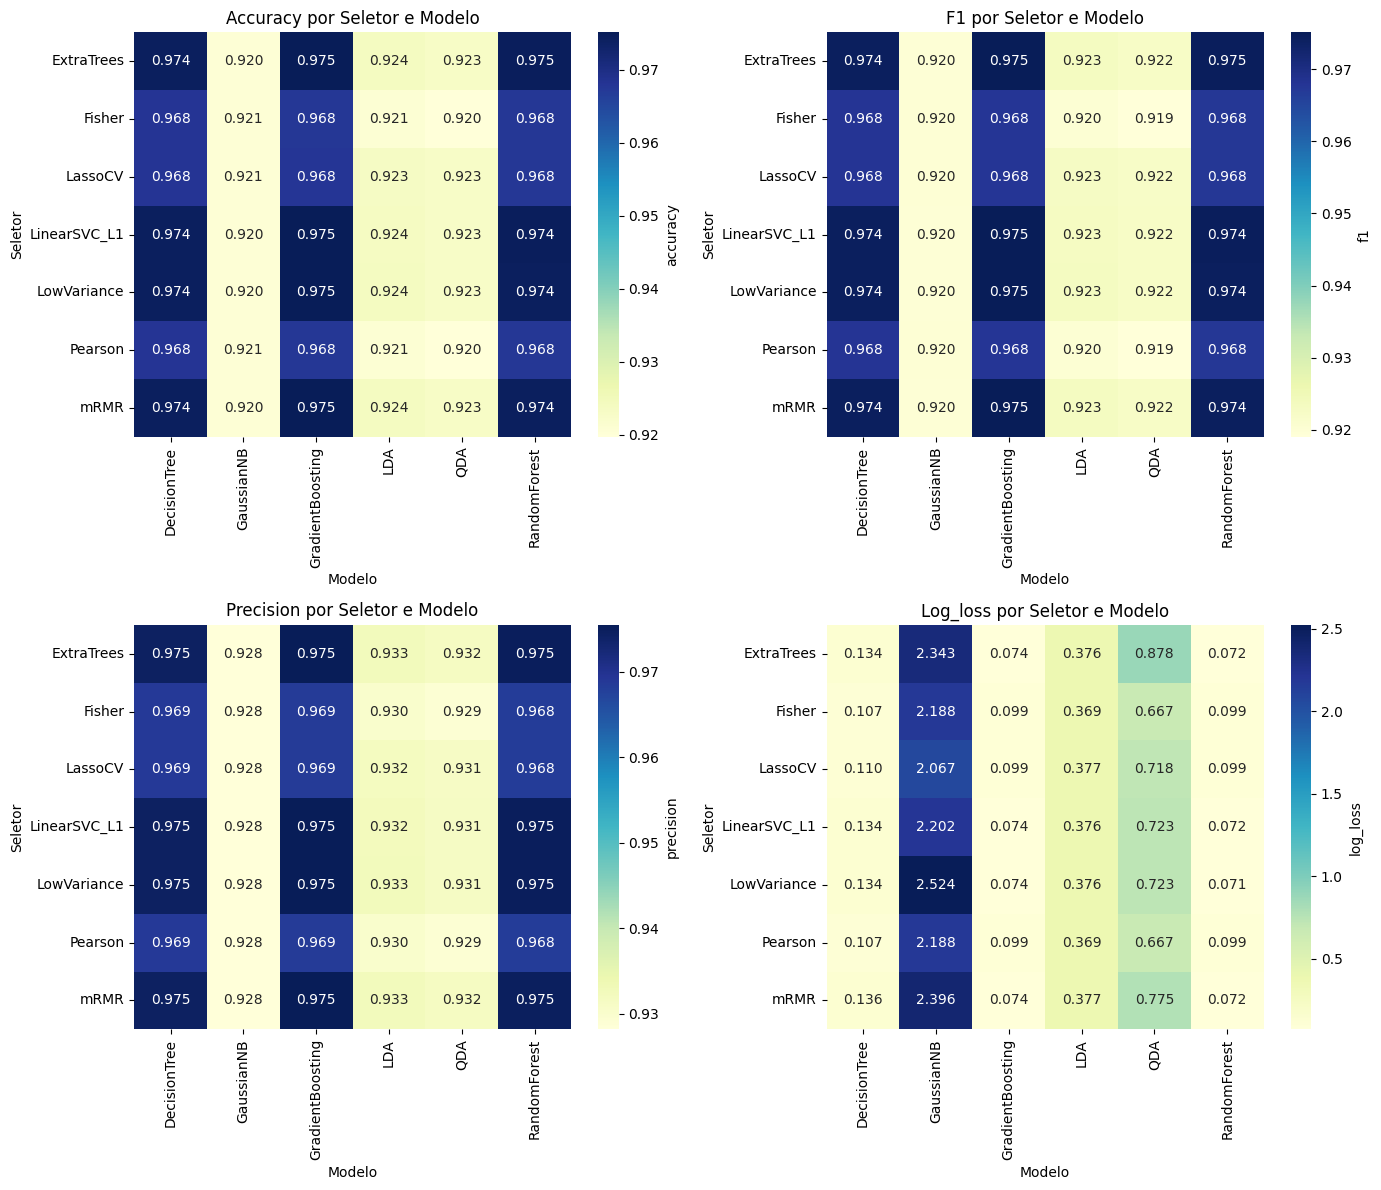

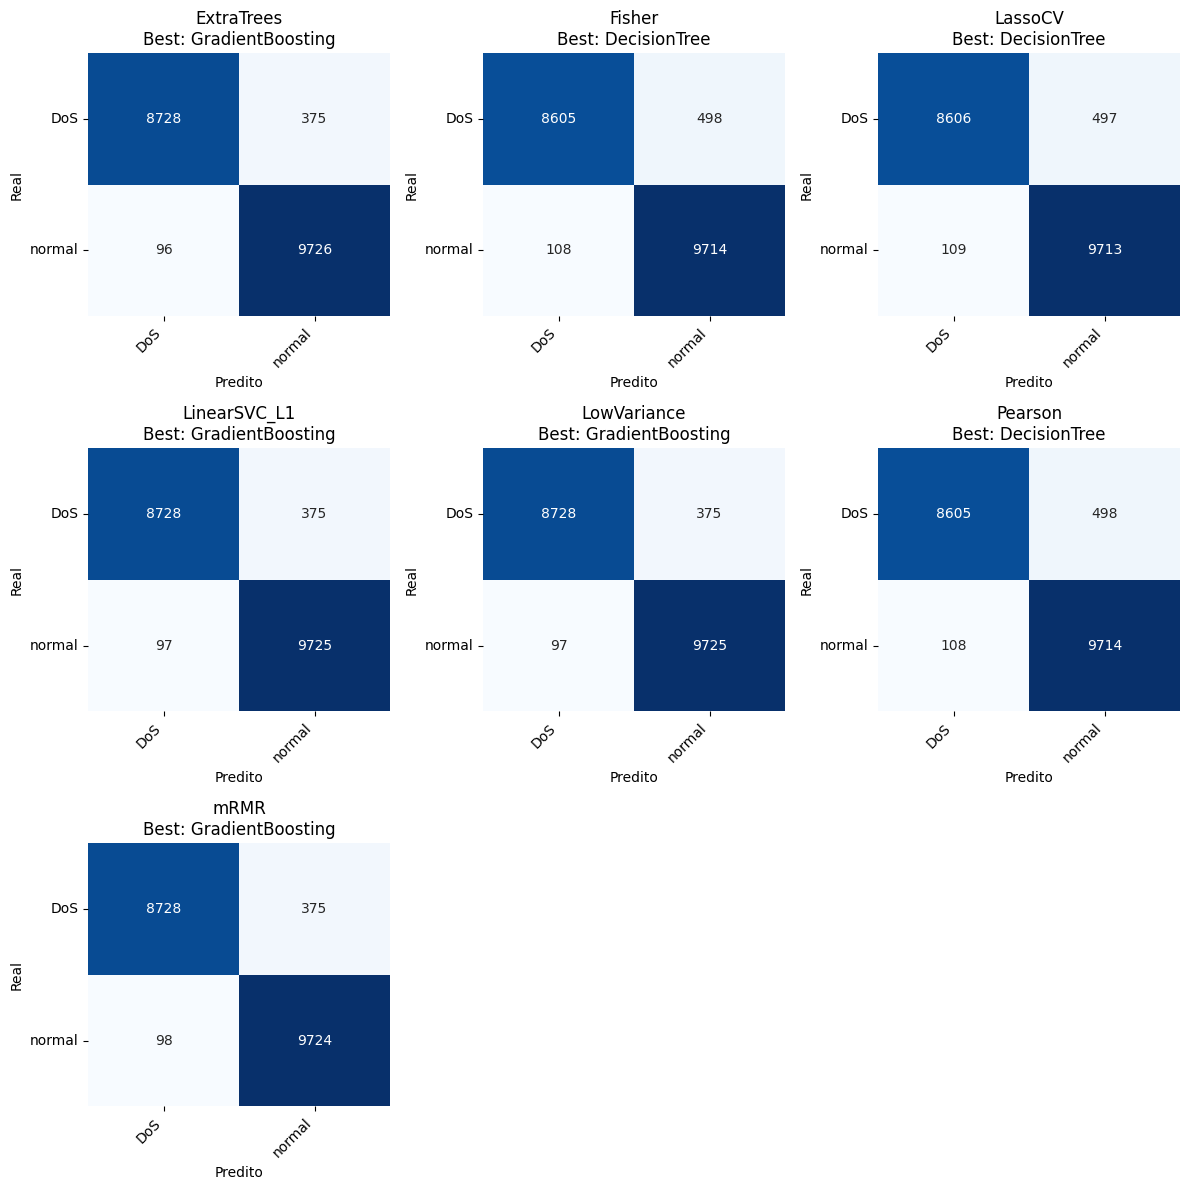

In [23]:
# Visualizar resultados da selecao
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, metric in enumerate(['accuracy', 'f1', 'precision', 'log_loss']):
    ax = axes[idx // 2, idx % 2]
    pivot = selection_df.pivot(index='seletor', columns='modelo', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric.capitalize()} por Seletor e Modelo')
    ax.set_xlabel('Modelo')
    ax.set_ylabel('Seletor')
plt.tight_layout()
plt.savefig('../reports/reports_ensemble_v2/selection_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# Visualizacao: melhor matriz de confusao por seletor
selectors_order = sorted(best_confusion_matrix_by_selector.keys())
n_sel = len(selectors_order)
n_cols = 3
n_rows = int(np.ceil(n_sel / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)
class_labels = sorted(y_test.unique())
for idx, selector_name in enumerate(selectors_order):
    ax = axes[idx]
    payload = best_confusion_matrix_by_selector[selector_name]
    cm = np.array(payload['confusion_matrix'])
    model_name = payload['modelo']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f"{selector_name}\nBest: {model_name}")
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.set_yticklabels(class_labels, rotation=0)
for j in range(len(selectors_order), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig('../reports/reports_ensemble_v2/best_confusion_by_selector.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Otimização de Hiperparâmetros com Optuna

Otimizar os hiperparâmetros dos melhores modelos encontrados.

In [24]:
# Preparar os dados de consenso antes de iniciar o Optuna
X_train_cons = X_train[consensus_features]
X_test_cons = X_test[consensus_features]
X_train_cons_scaled = X_train_scaled[consensus_features]
X_test_cons_scaled = X_test_scaled[consensus_features]



# Definir espacos de busca e funcao objetivo do Optuna para os 6 modelos
# [REGULARIZADO] Espaços de buscas ajustados para prevenir overfitting (DT/RF) e underfitting (LDA/QDA/NB)
from optuna.exceptions import TrialPruned
optuna_model_names = ['LDA', 'QDA', 'GaussianNB', 'DecisionTree', 'RandomForest', 'GradientBoosting']
def build_model_from_trial(model_name, trial):
    if model_name == 'LDA':
        # Evita solver 'eigen' por instabilidade numerica neste dataset
        solver = trial.suggest_categorical('solver', ['svd', 'lsqr'])
        if solver == 'lsqr':
            # [REGULARIZADO] shrinkage como float 0.0-0.3 para busca mais fina
            shrinkage = trial.suggest_float('shrinkage', 0.0, 0.3)
            tol = trial.suggest_float('tol', 1e-6, 1e-3, log=True)
            return LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage, tol=tol)
        tol = trial.suggest_float('tol', 1e-6, 1e-3, log=True)
        return LinearDiscriminantAnalysis(solver=solver, tol=tol)
    if model_name == 'QDA':
        # [REGULARIZADO] Foco em 1e-4 a 0.1 (escala log) para evitar over-regularizacao
        # NOTA: log=True exige lower > 0; 1e-4 substitui 0.0 como limite inferior
        reg_param = trial.suggest_float('reg_param', 1e-4, 0.1, log=True)
        return QuadraticDiscriminantAnalysis(reg_param=reg_param)
    if model_name == 'GaussianNB':
        # [REGULARIZADO] Ampliar range para 1e-9 a 1e-5 (mais smoothing disponivel)
        var_smoothing = trial.suggest_float('var_smoothing', 1e-9, 1e-5, log=True)
        return GaussianNB(var_smoothing=var_smoothing)
    if model_name == 'DecisionTree':
        # [REGULARIZADO] max_depth 4-8; min_samples_split/leaf 20-100; max_features 
        return DecisionTreeClassifier(
            max_depth=trial.suggest_int('max_depth', 4, 8),
            min_samples_split=trial.suggest_int('min_samples_split', 20, 100),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 20, 100),
            max_features=trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
            random_state=RANDOM_STATE,
        )
    if model_name == 'RandomForest':
        # [REGULARIZADO] min_samples_leaf 10-50 (nunca 1!); max_features forcado; max_samples 
        return RandomForestClassifier(
            n_estimators=trial.suggest_int('n_estimators', 100, 300),
            max_depth=trial.suggest_int('max_depth', 6, 12),
            min_samples_split=trial.suggest_int('min_samples_split', 20, 100),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 10, 50),
            max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            max_samples=trial.suggest_float('max_samples', 0.7, 1.0),
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    if model_name == 'GradientBoosting':
        return GradientBoostingClassifier(
            n_estimators=trial.suggest_int('n_estimators', 30, 200),
            max_depth=trial.suggest_int('max_depth', 2, 8),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 15),
            random_state=RANDOM_STATE,
        )
    raise ValueError(f'Modelo nao suportado: {model_name}')
def objective_factory(model_name):
    def objective(trial):
        model = build_model_from_trial(model_name, trial)
        if model_name in MODELS_REQUIRING_SCALING:
            estimator = Pipeline([('scaler', StandardScaler()), ('model', model)])
            X_cv = X_train_cons
        else:
            estimator = model
            X_cv = X_train_cons
        try:
            scores = cross_val_score(
                estimator,
                X_cv,
                y_train,
                cv=3,
                scoring='f1_weighted',
                error_score=np.nan,
            )
            if np.isnan(scores).all():
                raise TrialPruned()
            return float(np.nanmean(scores))
        except Exception:
            raise TrialPruned()
    return objective
print('Objetivos Optuna definidos para os 6 modelos (com tratamento de falhas e busca enxuta)')
print('[REGULARIZADO] Search spaces atualizados: DT/RF regularizados, LDA/QDA/NB com ranges ampliados')



Objetivos Optuna definidos para os 6 modelos (com tratamento de falhas e busca enxuta)
[REGULARIZADO] Search spaces atualizados: DT/RF regularizados, LDA/QDA/NB com ranges ampliados


In [25]:
# Executar otimizacao com Optuna
trial_budget = {
    'LDA': 10,
    'QDA': 10,
    'GaussianNB': 10,
    'DecisionTree': 12,
    'RandomForest': 12,
    'GradientBoosting': 12,
}
optuna_studies = {}
failed_optuna_models = []
optuna_global_timing_records = []
print('Otimizando hiperparametros com budget reduzido por modelo...')
for model_name in optuna_model_names:
    n_trials = trial_budget[model_name]
    print(f"\n- Otimizando {model_name} (n_trials={n_trials})")
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    optuna_start = time.perf_counter()
    try:
        study.optimize(objective_factory(model_name), n_trials=n_trials, show_progress_bar=False)
        optuna_elapsed = time.perf_counter() - optuna_start
        if study.best_trial is None:
            failed_optuna_models.append(model_name)
            append_timing_record(
                'optuna_global_optimization',
                modelo=model_name,
                n_trials=n_trials,
                n_cv_folds=3,
                tempo_otimizacao_sec=optuna_elapsed,
                tempo_total_sec=optuna_elapsed,
                status='failed_optimization',
                error_message='Sem trial valido',
            )
            print('  Sem trial valido; modelo sera ignorado no bloco otimizado.')
            continue
        optuna_studies[model_name] = study
        optuna_global_timing_records.append({
            'modelo': model_name,
            'tempo_otimizacao_sec': optuna_elapsed,
            'n_trials': n_trials,
            'n_cv_folds': 3,
            'best_f1_cv': study.best_value,
            'best_params': study.best_params,
        })
        append_timing_record(
            'optuna_global_optimization',
            modelo=model_name,
            n_trials=n_trials,
            n_cv_folds=3,
            tempo_otimizacao_sec=optuna_elapsed,
            tempo_total_sec=optuna_elapsed,
            status='success',
        )
        print(f"  Melhor F1 (CV): {study.best_value:.4f}")
        print(f"  Melhores params: {study.best_params}")
    except Exception as e:
        failed_optuna_models.append(model_name)
        optuna_elapsed = time.perf_counter() - optuna_start
        append_timing_record(
            'optuna_global_optimization',
            modelo=model_name,
            n_trials=n_trials,
            n_cv_folds=3,
            tempo_otimizacao_sec=optuna_elapsed,
            tempo_total_sec=optuna_elapsed,
            status='failed_optimization',
            error_message=str(e),
        )
        print(f"  Falha na otimizacao de {model_name}: {e}")
N_TRIALS = int(np.mean(list(trial_budget.values())))
if failed_optuna_models:
    print(f"\nModelos com falha na otimizacao: {failed_optuna_models}")
else:
    print('\nTodos os modelos foram otimizados com sucesso.')


[I 2026-06-02 15:42:18,669] A new study created in memory with name: no-name-643b08bc-6d4f-4dab-9c78-c7e97f6ed20c


Otimizando hiperparametros com budget reduzido por modelo...

- Otimizando LDA (n_trials=10)


[I 2026-06-02 15:42:19,041] Trial 0 finished with value: 0.9251810175910825 and parameters: {'solver': 'lsqr', 'shrinkage': 0.21959818254342153, 'tol': 6.251373574521755e-05}. Best is trial 0 with value: 0.9251810175910825.
[I 2026-06-02 15:42:19,514] Trial 1 finished with value: 0.9263160030232913 and parameters: {'solver': 'svd', 'tol': 1.493656855461763e-06}. Best is trial 1 with value: 0.9263160030232913.
[I 2026-06-02 15:42:20,008] Trial 2 finished with value: 0.9263160030232913 and parameters: {'solver': 'svd', 'tol': 0.000133112160807369}. Best is trial 1 with value: 0.9263160030232913.
[I 2026-06-02 15:42:20,396] Trial 3 finished with value: 0.9251153450136719 and parameters: {'solver': 'lsqr', 'shrinkage': 0.2497327922401265, 'tol': 4.335281794951567e-06}. Best is trial 1 with value: 0.9263160030232913.
[I 2026-06-02 15:42:20,768] Trial 4 finished with value: 0.9256175827216415 and parameters: {'solver': 'lsqr', 'shrinkage': 0.09127267288786131, 'tol': 3.752055855124284e-05}. 

  Melhor F1 (CV): 0.9263
  Melhores params: {'solver': 'svd', 'tol': 1.493656855461763e-06}

- Otimizando QDA (n_trials=10)


[I 2026-06-02 15:42:23,623] Trial 0 finished with value: 0.9252901468474545 and parameters: {'reg_param': 0.0013292918943162175}. Best is trial 0 with value: 0.9252901468474545.
[I 2026-06-02 15:42:24,138] Trial 1 finished with value: 0.9256055520393637 and parameters: {'reg_param': 0.07114476009343425}. Best is trial 1 with value: 0.9256055520393637.
[I 2026-06-02 15:42:24,654] Trial 2 finished with value: 0.9256447406220095 and parameters: {'reg_param': 0.015702970884055395}. Best is trial 2 with value: 0.9256447406220095.
[I 2026-06-02 15:42:25,169] Trial 3 finished with value: 0.9256972884058848 and parameters: {'reg_param': 0.006251373574521752}. Best is trial 3 with value: 0.9256972884058848.
[I 2026-06-02 15:42:25,689] Trial 4 finished with value: 0.9244352374442887 and parameters: {'reg_param': 0.00029380279387035364}. Best is trial 3 with value: 0.9256972884058848.
[I 2026-06-02 15:42:26,208] Trial 5 finished with value: 0.9244352374442887 and parameters: {'reg_param': 0.00029

...

  Melhor F1 (CV): 0.9710
  Melhores params: {'max_depth': 5, 'min_samples_split': 97, 'min_samples_leaf': 79, 'max_features': None}

- Otimizando RandomForest (n_trials=12)


[I 2026-06-02 15:42:37,678] Trial 0 finished with value: 0.9700656895480534 and parameters: {'n_estimators': 175, 'max_depth': 12, 'min_samples_split': 79, 'min_samples_leaf': 34, 'max_features': 'sqrt', 'max_samples': 0.7174250836504598}. Best is trial 0 with value: 0.9700656895480534.
[I 2026-06-02 15:42:42,157] Trial 1 finished with value: 0.9716305017705845 and parameters: {'n_estimators': 274, 'max_depth': 10, 'min_samples_split': 77, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.7637017332034828}. Best is trial 1 with value: 0.9716305017705845.
[I 2026-06-02 15:42:44,403] Trial 2 finished with value: 0.9683686426767976 and parameters: {'n_estimators': 136, 'max_depth': 7, 'min_samples_split': 44, 'min_samples_leaf': 31, 'max_features': 'sqrt', 'max_samples': 0.8835558684167139}. Best is trial 1 with value: 0.9716305017705845.
[I 2026-06-02 15:42:46,565] Trial 3 finished with value: 0.9685800241650031 and parameters: {'n_estimators': 128, 'max_depth': 8, 'min_sa

  Melhor F1 (CV): 0.9716
  Melhores params: {'n_estimators': 274, 'max_depth': 10, 'min_samples_split': 77, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.7637017332034828}

- Otimizando GradientBoosting (n_trials=12)


[I 2026-06-02 15:43:23,185] Trial 0 finished with value: 0.9732876046232302 and parameters: {'n_estimators': 94, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'min_samples_split': 10}. Best is trial 0 with value: 0.9732876046232302.
[I 2026-06-02 15:43:26,045] Trial 1 finished with value: 0.9642724781868637 and parameters: {'n_estimators': 56, 'max_depth': 3, 'learning_rate': 0.012184186502221764, 'min_samples_split': 14}. Best is trial 0 with value: 0.9732876046232302.
[I 2026-06-02 15:43:36,807] Trial 2 finished with value: 0.9741792129940902 and parameters: {'n_estimators': 132, 'max_depth': 6, 'learning_rate': 0.010725209743171997, 'min_samples_split': 15}. Best is trial 2 with value: 0.9741792129940902.
[I 2026-06-02 15:43:45,221] Trial 3 finished with value: 0.9663966763582771 and parameters: {'n_estimators': 172, 'max_depth': 3, 'learning_rate': 0.01855998084649059, 'min_samples_split': 4}. Best is trial 2 with value: 0.9741792129940902.
[I 2026-06-02 15:43:51,229] Trial 

  Melhor F1 (CV): 0.9747
  Melhores params: {'n_estimators': 191, 'max_depth': 6, 'learning_rate': 0.03504750508385013, 'min_samples_split': 11}

Todos os modelos foram otimizados com sucesso.


In [26]:
# Resumo das melhores configuracoes encontradas
best_params_rows = []
for model_name, study in optuna_studies.items():
    best_params_rows.append({
        'modelo': model_name,
        'best_f1_cv': study.best_value,
        'best_params': json.dumps(study.best_params),
    })
if best_params_rows:
    best_params_df = pd.DataFrame(best_params_rows).sort_values('best_f1_cv', ascending=False)
    print("\nResumo dos melhores parametros por modelo:")
    print(best_params_df.to_string(index=False))
    best_params_df.to_csv('../reports/reports_ensemble_v2/optuna_best_params_summary.csv', index=False)
else:
    best_params_df = pd.DataFrame(columns=['modelo', 'best_f1_cv', 'best_params'])
    print('Nenhum estudo Optuna valido para resumir.')



Resumo dos melhores parametros por modelo:
          modelo  best_f1_cv                                                                                                                                        best_params
GradientBoosting    0.974659                                               {"n_estimators": 191, "max_depth": 6, "learning_rate": 0.03504750508385013, "min_samples_split": 11}
    RandomForest    0.971631 {"n_estimators": 274, "max_depth": 10, "min_samples_split": 77, "min_samples_leaf": 10, "max_features": "sqrt", "max_samples": 0.7637017332034828}
    DecisionTree    0.971031                                                            {"max_depth": 5, "min_samples_split": 97, "min_samples_leaf": 79, "max_features": null}
             LDA    0.926316                                                                                                    {"solver": "svd", "tol": 1.493656855461763e-06}
             QDA    0.925776                                                

In [27]:
# Treinar modelos otimizados e avaliar no conjunto de teste
print("\n" + "=" * 70)
print("AVALIACAO FINAL - MODELOS OTIMIZADOS")
print("=" * 70)
optuna_results = []
optuna_confusion_matrices = {}
optuna_trained_models = {}
if not optuna_studies:
    print('Nenhum modelo otimizado disponivel para avaliacao final.')
else:
    for model_name in optuna_studies.keys():
        best_params = optuna_studies[model_name].best_params
        base_model = baseline_models[model_name].__class__(**best_params)
        if 'random_state' in baseline_models[model_name].get_params():
            try:
                base_model.set_params(random_state=RANDOM_STATE)
            except ValueError:
                pass
        result = evaluate_model(
            model_name=model_name,
            model=base_model,
            X_train_raw=X_train_cons,
            X_test_raw=X_test_cons,
            X_train_scaled=X_train_cons_scaled,
            X_test_scaled=X_test_cons_scaled,
            y_train=y_train,
            y_test=y_test,
        )
        metrics = result['metrics']
        optuna_results.append({
            'modelo': f'{model_name} (Optuna)',
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'f1': metrics['f1'],
            'log_loss': metrics['log_loss'],
            'fp_per_class': result['fp_per_class'],
            'fn_per_class': result['fn_per_class'],
        })
        optuna_confusion_matrices[f'{model_name} (Optuna)'] = result['confusion_matrix'].tolist()
        optuna_trained_models[model_name] = base_model
        append_timing_record(
            'optuna_global_training',
            modelo=model_name,
            n_features=len(consensus_features),
            tempo_fit_sec=result['tempo_fit_sec'],
            tempo_predict_sec=result['tempo_predict_sec'],
            tempo_proba_sec=result['tempo_proba_sec'],
            tempo_total_sec=result['tempo_total_sec'],
        )
        print(
            f"{model_name}: Acc={metrics['accuracy']:.4f}, "
            f"Prec={metrics['precision']:.4f}, F1={metrics['f1']:.4f}, "
            f"LogLoss={metrics['log_loss']:.4f}"
        )



AVALIACAO FINAL - MODELOS OTIMIZADOS
LDA: Acc=0.9236, Prec=0.9324, F1=0.9230, LogLoss=0.3765
QDA: Acc=0.9231, Prec=0.9315, F1=0.9225, LogLoss=0.9839
GaussianNB: Acc=0.9234, Prec=0.9328, F1=0.9227, LogLoss=1.1933
DecisionTree: Acc=0.9711, Prec=0.9717, F1=0.9711, LogLoss=0.0821
RandomForest: Acc=0.9732, Prec=0.9740, F1=0.9732, LogLoss=0.0958
GradientBoosting: Acc=0.9754, Prec=0.9757, F1=0.9754, LogLoss=0.0714



Resultados dos Modelos Otimizados:
                   modelo  accuracy  precision       f1  log_loss fp_per_class fn_per_class
GradientBoosting (Optuna)  0.975376   0.975733 0.975358  0.071406    [99, 367]    [367, 99]
    RandomForest (Optuna)  0.973210   0.974030 0.973176  0.095810    [52, 455]    [455, 52]
    DecisionTree (Optuna)  0.971096   0.971715 0.971066  0.082084    [97, 450]    [450, 97]
             LDA (Optuna)  0.923646   0.932385 0.923029  0.376519   [38, 1407]   [1407, 38]
      GaussianNB (Optuna)  0.923382   0.932785 0.922725  1.193321   [16, 1434]   [1434, 16]
             QDA (Optuna)  0.923065   0.931535 0.922457  0.983869   [53, 1403]   [1403, 53]


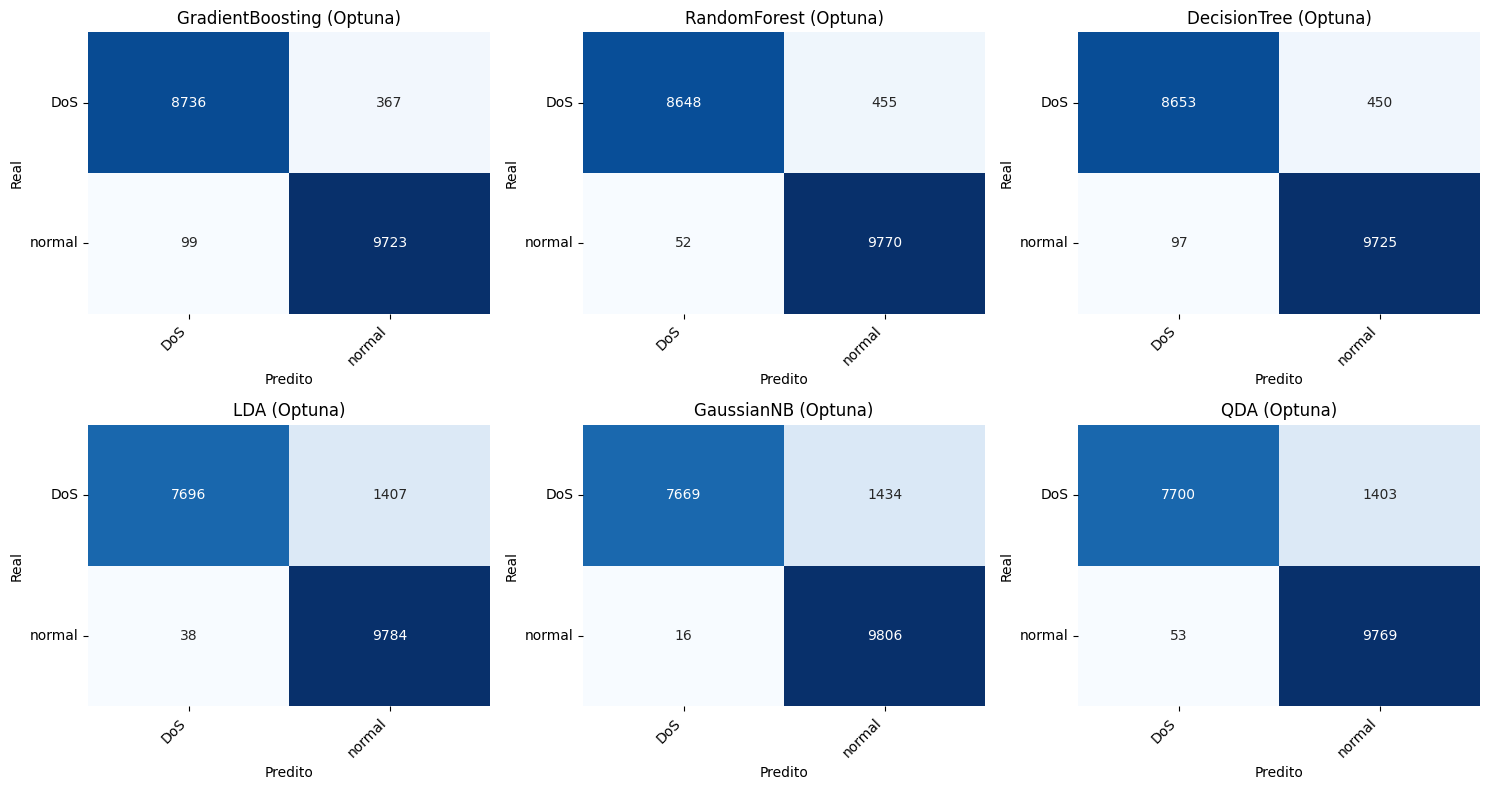

In [28]:
# Criar DataFrame de resultados otimizados e salvar
optuna_df = pd.DataFrame(optuna_results)
if optuna_df.empty:
    print('Sem resultados otimizados para salvar.')
    optuna_df = pd.DataFrame(columns=['modelo', 'accuracy', 'precision', 'f1', 'log_loss', 'fp_per_class', 'fn_per_class'])
else:
    optuna_df = optuna_df.sort_values('f1', ascending=False)
    print("\nResultados dos Modelos Otimizados:")
    print(optuna_df.to_string(index=False))
optuna_df.to_csv('../reports/reports_ensemble_v2/optuna_results.csv', index=False)
with open('../reports/reports_ensemble_v2/optuna_confusion_matrices.json', 'w') as f:
    json.dump(optuna_confusion_matrices, f, indent=2)
# Visualizar matrizes de confusao dos modelos otimizados
if not optuna_df.empty:
    n_models = len(optuna_df)
    n_cols = 3
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    class_labels = sorted(y_test.unique())
    for idx, row in enumerate(optuna_df.itertuples()):
        ax = axes[idx]
        cm = np.array(optuna_confusion_matrices[row.modelo])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(row.modelo)
        ax.set_xlabel('Predito')
        ax.set_ylabel('Real')
        ax.set_xticklabels(class_labels, rotation=45, ha='right')
        ax.set_yticklabels(class_labels, rotation=0)
    for j in range(n_models, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.savefig('../reports/reports_ensemble_v2/optuna_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()


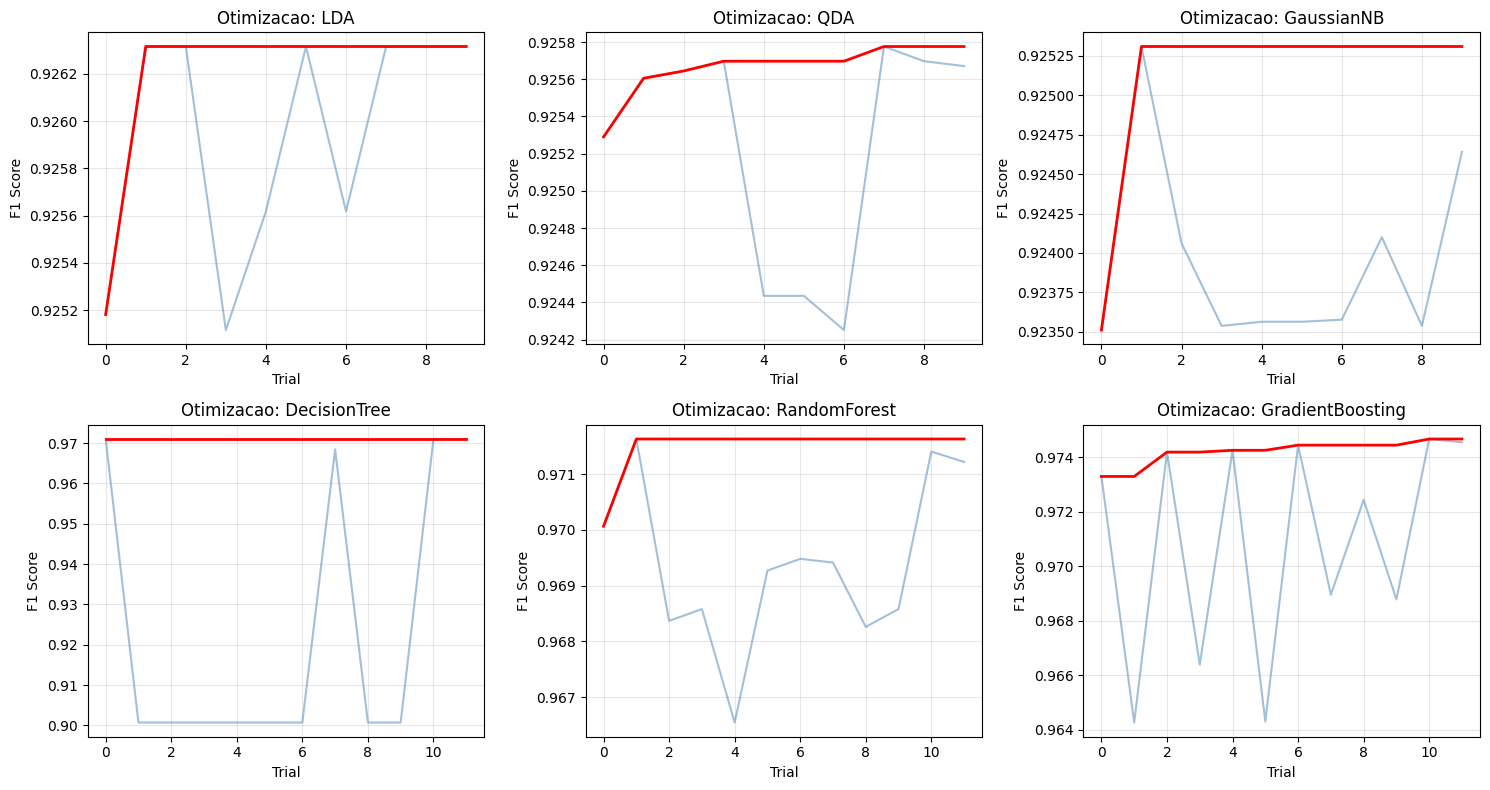

In [29]:
# Visualizar historico de otimizacao
if not optuna_studies:
    print('Sem estudos Optuna validos para plotar historico.')
else:
    n_models = len(optuna_studies)
    n_cols = 3
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for idx, (name, study) in enumerate(optuna_studies.items()):
        values = [trial.value for trial in study.trials if trial.value is not None]
        axes[idx].plot(values, alpha=0.5, color='steelblue')
        axes[idx].plot(np.maximum.accumulate(values), color='red', linewidth=2)
        axes[idx].set_xlabel('Trial')
        axes[idx].set_ylabel('F1 Score')
        axes[idx].set_title(f'Otimizacao: {name}')
        axes[idx].grid(True, alpha=0.3)
    for j in range(n_models, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.savefig('../reports/reports_ensemble_v2/optuna_optimization_history.png', dpi=150, bbox_inches='tight')
    plt.show()


## Ensemble com Modelos Otimizados
Utilizando as predições dos modelos que já foram otimizados pelo Optuna.

In [30]:
import time
import numpy as np
from scipy.stats import mode
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, log_loss

# 0. Setup: Gerar predições dos modelos otimizados
print("Gerando predições dos modelos otimizados...")

if not optuna_trained_models:
    print("AVISO: Nenhum modelo otimizado foi encontrado. Rode o bloco do Optuna primeiro.")
    ensemble_model_names_opt = []
    probs_stack_opt = np.array([])
    preds_stack_opt = np.array([])
else:
    ensemble_model_names_opt = list(optuna_trained_models.keys())
    classes = sorted(y_test.unique())

    optuna_predictions = {}
    for name, model in optuna_trained_models.items():
        if name in MODELS_REQUIRING_SCALING:
            Xte = X_test_cons_scaled
        else:
            Xte = X_test_cons
        
        probs = model.predict_proba(Xte)
        preds = model.predict(Xte)
        optuna_predictions[name] = {'probabilities': probs, 'predictions': preds}

    probs_stack_opt = np.stack([optuna_predictions[m]['probabilities'] for m in ensemble_model_names_opt], axis=0)
    preds_stack_opt = np.stack([optuna_predictions[m]['predictions'] for m in ensemble_model_names_opt], axis=0)
    print(f"Predições geradas para {len(ensemble_model_names_opt)} modelos.")


Gerando predições dos modelos otimizados...
Predições geradas para 6 modelos.


In [31]:
# 1. Averaging (Média simples das probabilidades)
print("=" * 70)
print("ENSEMBLE - AVERAGING (MODELOS OTIMIZADOS)")
print("=" * 70)
averaging_start = time.perf_counter()

avg_probs = probs_stack_opt.mean(axis=0)
y_pred_averaging = np.array(classes)[np.argmax(avg_probs, axis=1)]
cm_averaging = confusion_matrix(y_test, y_pred_averaging, labels=classes)

averaging_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_averaging),
    'precision': precision_score(y_test, y_pred_averaging, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_averaging, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, avg_probs, labels=classes),
}

averaging_fp = (cm_averaging.sum(axis=0) - np.diag(cm_averaging)).tolist()
averaging_fn = (cm_averaging.sum(axis=1) - np.diag(cm_averaging)).tolist()
averaging_total_sec = time.perf_counter() - averaging_start

append_timing_record(
    'ensemble_averaging',
    tempo_total_sec=averaging_total_sec,
    status='success',
)

print("Métricas Averaging:")
for metric, value in averaging_metrics.items():
    print(f"  {metric}: {value:.4f}")


ENSEMBLE - AVERAGING (MODELOS OTIMIZADOS)
Métricas Averaging:
  accuracy: 0.9258
  precision: 0.9351
  f1: 0.9252
  log_loss: 0.1157


In [32]:
# 2. Hard Voting (Voto Majoritário)
print("=" * 70)
print("ENSEMBLE - HARD VOTING (MODELOS OTIMIZADOS)")
print("=" * 70)
hard_voting_start = time.perf_counter()

import pandas as pd
# Substituindo scipy.stats.mode por pandas para suportar strings (classes)
y_pred_hard = pd.DataFrame(preds_stack_opt).mode(axis=0).iloc[0].values
cm_hard = confusion_matrix(y_test, y_pred_hard, labels=classes)

hard_voting_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_hard),
    'precision': precision_score(y_test, y_pred_hard, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_hard, average='weighted', zero_division=0),
    'log_loss': np.nan, # Hard voting não produz probabilidades válidas para log loss nativo
}

hard_voting_fp = (cm_hard.sum(axis=0) - np.diag(cm_hard)).tolist()
hard_voting_fn = (cm_hard.sum(axis=1) - np.diag(cm_hard)).tolist()
hard_voting_total_sec = time.perf_counter() - hard_voting_start

append_timing_record(
    'ensemble_hard_voting',
    tempo_total_sec=hard_voting_total_sec,
    status='success',
)

print("Métricas Hard Voting:")
for metric, value in hard_voting_metrics.items():
    print(f"  {metric}: {value:.4f}")


ENSEMBLE - HARD VOTING (MODELOS OTIMIZADOS)
Métricas Hard Voting:
  accuracy: 0.9716
  precision: 0.9723
  f1: 0.9715
  log_loss: nan


In [33]:
# 3. Smart Soft Voting (Pesos Otimizados via Optuna)
print("=" * 70)
print("ENSEMBLE - SMART SOFT VOTING (PESOS OTIMIZADOS)")
print("=" * 70)
smart_voting_start = time.perf_counter()

def ensemble_objective(trial):
    weights = [trial.suggest_float(f'w_{m}', 0.0, 1.0) for m in ensemble_model_names_opt]
    w_array = np.array(weights)
    if w_array.sum() == 0:
        return 0.0
    w_array = w_array / w_array.sum()
    
    weighted_probs = np.tensordot(w_array, probs_stack_opt, axes=(0, 0))
    y_pred = np.array(classes)[np.argmax(weighted_probs, axis=1)]
    return f1_score(y_test, y_pred, average='weighted', zero_division=0)

study_ensemble = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_ensemble.optimize(ensemble_objective, n_trials=100, show_progress_bar=False)

best_weights = np.array([study_ensemble.best_params[f'w_{m}'] for m in ensemble_model_names_opt])
if best_weights.sum() > 0:
    best_weights = best_weights / best_weights.sum()
else:
    best_weights = np.ones(len(best_weights)) / len(best_weights)

print("Pesos otimizados pelo Optuna:")
for m, w in zip(ensemble_model_names_opt, best_weights):
    print(f"  {m}: {w:.4f}")

weighted_probs_opt = np.tensordot(best_weights, probs_stack_opt, axes=(0, 0))
y_pred_smart = np.array(classes)[np.argmax(weighted_probs_opt, axis=1)]
cm_smart = confusion_matrix(y_test, y_pred_smart, labels=classes)

smart_voting_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_smart),
    'precision': precision_score(y_test, y_pred_smart, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_smart, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, weighted_probs_opt, labels=classes),
}

smart_voting_fp = (cm_smart.sum(axis=0) - np.diag(cm_smart)).tolist()
smart_voting_fn = (cm_smart.sum(axis=1) - np.diag(cm_smart)).tolist()
smart_voting_total_sec = time.perf_counter() - smart_voting_start

append_timing_record(
    'ensemble_smart_voting',
    tempo_total_sec=smart_voting_total_sec,
    status='success',
)

print("\nMétricas Smart Soft Voting:")
for metric, value in smart_voting_metrics.items():
    print(f"  {metric}: {value:.4f}")


[I 2026-06-02 15:45:07,289] A new study created in memory with name: no-name-dbf25f78-6241-4e34-9a53-f19645cdf78f
[I 2026-06-02 15:45:07,321] Trial 0 finished with value: 0.9234567073450491 and parameters: {'w_LDA': 0.3745401188473625, 'w_QDA': 0.9507143064099162, 'w_GaussianNB': 0.7319939418114051, 'w_DecisionTree': 0.5986584841970366, 'w_RandomForest': 0.15601864044243652, 'w_GradientBoosting': 0.15599452033620265}. Best is trial 0 with value: 0.9234567073450491.
[I 2026-06-02 15:45:07,353] Trial 1 finished with value: 0.9584456255177706 and parameters: {'w_LDA': 0.05808361216819946, 'w_QDA': 0.8661761457749352, 'w_GaussianNB': 0.6011150117432088, 'w_DecisionTree': 0.7080725777960455, 'w_RandomForest': 0.020584494295802447, 'w_GradientBoosting': 0.9699098521619943}. Best is trial 1 with value: 0.9584456255177706.
[I 2026-06-02 15:45:07,385] Trial 2 finished with value: 0.925241166760564 and parameters: {'w_LDA': 0.8324426408004217, 'w_QDA': 0.21233911067827616, 'w_GaussianNB': 0.1818

ENSEMBLE - SMART SOFT VOTING (PESOS OTIMIZADOS)


[I 2026-06-02 15:45:07,512] Trial 6 finished with value: 0.9250265288417898 and parameters: {'w_LDA': 0.3046137691733707, 'w_QDA': 0.09767211400638387, 'w_GaussianNB': 0.6842330265121569, 'w_DecisionTree': 0.4401524937396013, 'w_RandomForest': 0.12203823484477883, 'w_GradientBoosting': 0.4951769101112702}. Best is trial 5 with value: 0.9729095718669238.
[I 2026-06-02 15:45:07,543] Trial 7 finished with value: 0.9596329342252355 and parameters: {'w_LDA': 0.034388521115218396, 'w_QDA': 0.9093204020787821, 'w_GaussianNB': 0.2587799816000169, 'w_DecisionTree': 0.662522284353982, 'w_RandomForest': 0.31171107608941095, 'w_GradientBoosting': 0.5200680211778108}. Best is trial 5 with value: 0.9729095718669238.
[I 2026-06-02 15:45:07,575] Trial 8 finished with value: 0.9628110168413839 and parameters: {'w_LDA': 0.5467102793432796, 'w_QDA': 0.18485445552552704, 'w_GaussianNB': 0.9695846277645586, 'w_DecisionTree': 0.7751328233611146, 'w_RandomForest': 0.9394989415641891, 'w_GradientBoosting': 0.

Pesos otimizados pelo Optuna:
  LDA: 0.0473
  QDA: 0.0437
  GaussianNB: 0.0916
  DecisionTree: 0.1150
  RandomForest: 0.1059
  GradientBoosting: 0.5965

Métricas Smart Soft Voting:
  accuracy: 0.9746
  precision: 0.9753
  f1: 0.9746
  log_loss: 0.0829


In [34]:
# Comparar metodos de ensemble atualizados
ensemble_comparison = pd.DataFrame([
    {'Metodo': 'Averaging', **averaging_metrics},
    {'Metodo': 'Hard Voting', **hard_voting_metrics},
    {'Metodo': 'Smart Soft Voting', **smart_voting_metrics},
])

print("\nComparacao dos Metodos de Ensemble (Otimizados):")
print(ensemble_comparison.to_string(index=False))

ensemble_comparison.to_csv('../reports/reports_ensemble_v2/ensemble_results.csv', index=False)
np.save('../reports/reports_ensemble_v2/cm_averaging.npy', cm_averaging)
np.save('../reports/reports_ensemble_v2/cm_hard_voting.npy', cm_hard)
np.save('../reports/reports_ensemble_v2/cm_smart_voting.npy', cm_smart)
print('OK: resultados e matrizes de ensemble salvos')



Comparacao dos Metodos de Ensemble (Otimizados):
           Metodo  accuracy  precision       f1  log_loss
        Averaging  0.925812   0.935063 0.925189  0.115702
      Hard Voting  0.971572   0.972270 0.971539       NaN
Smart Soft Voting  0.974637   0.975298 0.974609  0.082883
OK: resultados e matrizes de ensemble salvos


## 10. Otimização com Optuna por Seletor de Features

Aplicar Optuna em cada conjunto de features selecionadas, mantendo os 6 modelos obrigatórios e salvando os modelos otimizados em diretórios dedicados.

In [35]:
# Optuna por seletor de features (7 seletores x 6 modelos)
import joblib
from optuna.trial import FixedTrial
models_optuna_dir = Path('../models/models_ensemble_v2/optuna')
models_refactored_dir = Path('../models/models_ensemble_v2/base')
models_optuna_dir.mkdir(parents=True, exist_ok=True)
models_refactored_dir.mkdir(parents=True, exist_ok=True)
def sanitize_name(name):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in name).strip('_')
def objective_selector_factory(model_name, X_cv_selector):
    def objective(trial):
        model = build_model_from_trial(model_name, trial)
        if model_name in MODELS_REQUIRING_SCALING:
            estimator = Pipeline([('scaler', StandardScaler()), ('model', model)])
            X_cv = X_cv_selector
        else:
            estimator = model
            X_cv = X_cv_selector
        try:
            scores = cross_val_score(
                estimator,
                X_cv,
                y_train,
                cv=3,
                scoring='f1_weighted',
                error_score=np.nan,
            )
            if np.isnan(scores).all():
                raise TrialPruned()
            return float(np.nanmean(scores))
        except Exception:
            raise TrialPruned()
    return objective
optuna_by_selector_results = []
optuna_by_selector_confusion_matrices = {}
optuna_by_selector_best_params = {}
optuna_by_selector_studies = {}
optuna_by_selector_trained_models = {}
failed_optuna_by_selector = []
print('Otimizando hiperparametros por seletor...')
for selector_name, features in selected_features_dict.items():
    print(f"\nSeletor: {selector_name} ({len(features)} features)")
    X_train_sel = X_train[features]
    X_test_sel = X_test[features]
    X_train_sel_scaled = X_train_scaled[features]
    X_test_sel_scaled = X_test_scaled[features]
    optuna_by_selector_confusion_matrices[selector_name] = {}
    optuna_by_selector_best_params[selector_name] = {}
    optuna_by_selector_studies[selector_name] = {}
    for model_name in optuna_model_names:
        n_trials = trial_budget.get(model_name, 10)
        study = optuna.create_study(
            direction='maximize',
            sampler=TPESampler(seed=RANDOM_STATE),
        )
        optuna_selector_start = time.perf_counter()
        try:
            study.optimize(
                objective_selector_factory(model_name, X_train_sel),
                n_trials=n_trials,
                show_progress_bar=False,
            )
            optuna_selector_elapsed = time.perf_counter() - optuna_selector_start
            if study.best_trial is None:
                failed_optuna_by_selector.append((selector_name, model_name, 'sem_trial_valido'))
                append_timing_record(
                    'optuna_by_selector_optimization',
                    seletor=selector_name,
                    modelo=model_name,
                    n_features=len(features),
                    n_trials=n_trials,
                    n_cv_folds=3,
                    tempo_otimizacao_sec=optuna_selector_elapsed,
                    tempo_total_sec=optuna_selector_elapsed,
                    status='failed_optimization',
                    error_message='Sem trial valido',
                )
                continue
            optuna_by_selector_studies[selector_name][model_name] = study
            optuna_by_selector_best_params[selector_name][model_name] = {
                'best_f1_cv': float(study.best_value),
                'best_params': study.best_params,
            }
            append_timing_record(
                'optuna_by_selector_optimization',
                seletor=selector_name,
                modelo=model_name,
                n_features=len(features),
                n_trials=n_trials,
                n_cv_folds=3,
                tempo_otimizacao_sec=optuna_selector_elapsed,
                tempo_total_sec=optuna_selector_elapsed,
                status='success',
            )
            tuned_model = build_model_from_trial(model_name, FixedTrial(study.best_params))
            if 'random_state' in tuned_model.get_params():
                try:
                    tuned_model.set_params(random_state=RANDOM_STATE)
                except ValueError:
                    pass
            result = evaluate_model(
                model_name=model_name,
                model=tuned_model,
                X_train_raw=X_train_sel,
                X_test_raw=X_test_sel,
                X_train_scaled=X_train_sel_scaled,
                X_test_scaled=X_test_sel_scaled,
                y_train=y_train,
                y_test=y_test,
            )
            metrics = result['metrics']
            file_tag = f"optuna_by_selector_{sanitize_name(selector_name)}_{sanitize_name(model_name)}.pkl"
            model_path_optuna = models_optuna_dir / file_tag
            model_path_refactored = models_refactored_dir / file_tag
            dump_start = time.perf_counter()
            joblib.dump(tuned_model, model_path_optuna)
            joblib.dump(tuned_model, model_path_refactored)
            dump_elapsed = time.perf_counter() - dump_start

            # Salvar datasets de treino e teste para inferencia
            if model_name in MODELS_REQUIRING_SCALING:
                # Modelos que requerem scaling recebem os dados ja normalizados
                train_df = pd.DataFrame(X_train_sel_scaled, columns=features, index=X_train_sel.index).copy()
                test_df = pd.DataFrame(X_test_sel_scaled, columns=features, index=X_test_sel.index).copy()
            else:
                # Os demais modelos recebem as features brutas selecionadas
                train_df = X_train_sel.copy()
                test_df = X_test_sel.copy()

            train_df['type'] = y_train
            test_df['type'] = y_test

            train_file_tag = f"train_optuna_by_selector_{sanitize_name(selector_name)}_{sanitize_name(model_name)}.csv"
            test_file_tag = f"test_optuna_by_selector_{sanitize_name(selector_name)}_{sanitize_name(model_name)}.csv"
            train_path_inference = Path('../data/inference/train') / train_file_tag
            test_path_inference = Path('../data/inference/test') / test_file_tag
            train_path_inference.parent.mkdir(parents=True, exist_ok=True)
            test_path_inference.parent.mkdir(parents=True, exist_ok=True)
            train_df.to_csv(train_path_inference, index=False)
            test_df.to_csv(test_path_inference, index=False)
            optuna_by_selector_trained_models[(selector_name, model_name)] = tuned_model
            optuna_by_selector_confusion_matrices[selector_name][model_name] = result['confusion_matrix'].tolist()
            optuna_by_selector_results.append({
                'seletor': selector_name,
                'modelo': model_name,
                'n_features': len(features),
                'accuracy': metrics['accuracy'],
                'precision': metrics['precision'],
                'f1': metrics['f1'],
                'log_loss': metrics['log_loss'],
                'fp_per_class': result['fp_per_class'],
                'fn_per_class': result['fn_per_class'],
                'model_path_optuna': str(model_path_optuna),
                'model_path_refactored': str(model_path_refactored),
            })
            append_timing_record(
                'optuna_by_selector_training',
                seletor=selector_name,
                modelo=model_name,
                n_features=len(features),
                tempo_fit_sec=result['tempo_fit_sec'],
                tempo_predict_sec=result['tempo_predict_sec'],
                tempo_proba_sec=result['tempo_proba_sec'],
                tempo_joblib_dump_sec=dump_elapsed,
                tempo_total_sec=result['tempo_total_sec'] + dump_elapsed,
                status='success',
            )
            print(
                f"  {model_name}: F1 CV={study.best_value:.4f}, "
                f"Teste F1={metrics['f1']:.4f}, LogLoss={metrics['log_loss']:.4f}"
            )
        except Exception as e:
            optuna_selector_elapsed = time.perf_counter() - optuna_selector_start
            failed_optuna_by_selector.append((selector_name, model_name, str(e)))
            append_timing_record(
                'optuna_by_selector_optimization',
                seletor=selector_name,
                modelo=model_name,
                n_features=len(features),
                n_trials=n_trials,
                n_cv_folds=3,
                tempo_otimizacao_sec=optuna_selector_elapsed,
                tempo_total_sec=optuna_selector_elapsed,
                status='failed_optimization',
                error_message=str(e),
            )
            print(f"  Falha em {model_name}: {e}")
optuna_by_selector_df = pd.DataFrame(optuna_by_selector_results)
if optuna_by_selector_df.empty:
    print('\nNenhum resultado valido de Optuna por seletor foi gerado.')
    optuna_by_selector_df = pd.DataFrame(
        columns=[
            'seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1',
            'log_loss', 'fp_per_class', 'fn_per_class', 'model_path_optuna', 'model_path_refactored',
        ]
    )
    best_optuna_by_selector_df = pd.DataFrame(
        columns=[
            'seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1',
            'log_loss', 'model_path_optuna', 'model_path_refactored',
        ]
    )
else:
    optuna_by_selector_df = optuna_by_selector_df.sort_values(['seletor', 'f1'], ascending=[True, False])
    best_optuna_by_selector_df = optuna_by_selector_df.loc[
        optuna_by_selector_df.groupby('seletor')['f1'].idxmax()
    ].copy()
    best_optuna_by_selector_df = best_optuna_by_selector_df.sort_values('f1', ascending=False)
    print('\nMelhor modelo otimizado por seletor:')
    print(
        best_optuna_by_selector_df[
            ['seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1', 'log_loss']
        ].to_string(index=False)
    )
optuna_by_selector_df.to_csv('../reports/reports_ensemble_v2/optuna_by_selector_results.csv', index=False)
best_optuna_by_selector_df.to_csv('../reports/reports_ensemble_v2/best_optuna_model_by_selector.csv', index=False)
with open('../reports/reports_ensemble_v2/optuna_by_selector_best_params.json', 'w') as f:
    json.dump(optuna_by_selector_best_params, f, indent=2)
with open('../reports/reports_ensemble_v2/optuna_by_selector_confusion_matrices.json', 'w') as f:
    json.dump(optuna_by_selector_confusion_matrices, f, indent=2)
if not best_optuna_by_selector_df.empty:
    best_non_opt_by_selector = selection_df.loc[selection_df.groupby('seletor')['f1'].idxmax()][
        ['seletor', 'modelo', 'accuracy', 'precision', 'f1', 'log_loss']
    ].rename(
        columns={
            'modelo': 'modelo_sem_optuna',
            'accuracy': 'accuracy_sem_optuna',
            'precision': 'precision_sem_optuna',
            'f1': 'f1_sem_optuna',
            'log_loss': 'log_loss_sem_optuna',
        }
    )
    best_opt_summary = best_optuna_by_selector_df[
        ['seletor', 'modelo', 'accuracy', 'precision', 'f1', 'log_loss', 'model_path_optuna', 'model_path_refactored']
    ].rename(
        columns={
            'modelo': 'modelo_com_optuna',
            'accuracy': 'accuracy_com_optuna',
            'precision': 'precision_com_optuna',
            'f1': 'f1_com_optuna',
            'log_loss': 'log_loss_com_optuna',
        }
    )
    optuna_by_selector_comparison = best_non_opt_by_selector.merge(best_opt_summary, on='seletor', how='left')
    optuna_by_selector_comparison['delta_f1'] = (
        optuna_by_selector_comparison['f1_com_optuna'] - optuna_by_selector_comparison['f1_sem_optuna']
    )
else:
    optuna_by_selector_comparison = pd.DataFrame(
        columns=[
            'seletor',
            'modelo_sem_optuna', 'accuracy_sem_optuna', 'precision_sem_optuna', 'f1_sem_optuna', 'log_loss_sem_optuna',
            'modelo_com_optuna', 'accuracy_com_optuna', 'precision_com_optuna', 'f1_com_optuna', 'log_loss_com_optuna',
            'model_path_optuna', 'model_path_refactored', 'delta_f1',
        ]
    )
optuna_by_selector_comparison.to_csv('../reports/reports_ensemble_v2/optuna_by_selector_comparison_cenario1_constant.csv', index=False)
print('\nOK: artefatos de Optuna por seletor gerados:')
print('- reports_refactored/optuna_by_selector_results.csv')
print('- reports_refactored/best_optuna_model_by_selector.csv')
print('- reports_refactored/optuna_by_selector_best_params.json')
print('- reports_refactored/optuna_by_selector_confusion_matrices.json')
print('- reports_refactored/optuna_by_selector_comparison_cenario1_constant.csv')
print('- models/models_optuna/*.pkl')
print('- models/models_refactored/*.pkl')
if failed_optuna_by_selector:
    print(f"Falhas registradas: {len(failed_optuna_by_selector)}")


[I 2026-06-02 15:45:10,880] A new study created in memory with name: no-name-9449cc81-7386-4685-88e5-5e91dcaf8b75


Otimizando hiperparametros por seletor...

Seletor: LowVariance (12 features)


[I 2026-06-02 15:45:11,250] Trial 0 finished with value: 0.9250503574590289 and parameters: {'solver': 'lsqr', 'shrinkage': 0.21959818254342153, 'tol': 6.251373574521755e-05}. Best is trial 0 with value: 0.9250503574590289.
[I 2026-06-02 15:45:11,721] Trial 1 finished with value: 0.9264237734376636 and parameters: {'solver': 'svd', 'tol': 1.493656855461763e-06}. Best is trial 1 with value: 0.9264237734376636.
[I 2026-06-02 15:45:12,185] Trial 2 finished with value: 0.9264237734376636 and parameters: {'solver': 'svd', 'tol': 0.000133112160807369}. Best is trial 1 with value: 0.9264237734376636.
[I 2026-06-02 15:45:12,561] Trial 3 finished with value: 0.9249978229652861 and parameters: {'solver': 'lsqr', 'shrinkage': 0.2497327922401265, 'tol': 4.335281794951567e-06}. Best is trial 1 with value: 0.9264237734376636.
[I 2026-06-02 15:45:12,916] Trial 4 finished with value: 0.9255114789268134 and parameters: {'solver': 'lsqr', 'shrinkage': 0.09127267288786131, 'tol': 3.752055855124284e-05}. 

  LDA: F1 CV=0.9264, Teste F1=0.9232, LogLoss=0.3764


[I 2026-06-02 15:45:16,606] Trial 0 finished with value: 0.9251453142880371 and parameters: {'reg_param': 0.0013292918943162175}. Best is trial 0 with value: 0.9251453142880371.
[I 2026-06-02 15:45:16,961] Trial 1 finished with value: 0.9255927557842506 and parameters: {'reg_param': 0.07114476009343425}. Best is trial 1 with value: 0.9255927557842506.
[I 2026-06-02 15:45:17,321] Trial 2 finished with value: 0.9263192815730896 and parameters: {'reg_param': 0.015702970884055395}. Best is trial 2 with value: 0.9263192815730896.
[I 2026-06-02 15:45:17,708] Trial 3 finished with value: 0.9256181063428289 and parameters: {'reg_param': 0.006251373574521752}. Best is trial 2 with value: 0.9263192815730896.
[I 2026-06-02 15:45:18,149] Trial 4 finished with value: 0.9240553816956895 and parameters: {'reg_param': 0.00029380279387035364}. Best is trial 2 with value: 0.9263192815730896.
[I 2026-06-02 15:45:18,520] Trial 5 finished with value: 0.9240553816956895 and parameters: {'reg_param': 0.00029

...

  DecisionTree: F1 CV=0.9710, Teste F1=0.9711, LogLoss=0.0821


[I 2026-06-02 15:59:30,843] Trial 0 finished with value: 0.9699601655385118 and parameters: {'n_estimators': 175, 'max_depth': 12, 'min_samples_split': 79, 'min_samples_leaf': 34, 'max_features': 'sqrt', 'max_samples': 0.7174250836504598}. Best is trial 0 with value: 0.9699601655385118.
[I 2026-06-02 15:59:35,150] Trial 1 finished with value: 0.9716845333657802 and parameters: {'n_estimators': 274, 'max_depth': 10, 'min_samples_split': 77, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.7637017332034828}. Best is trial 1 with value: 0.9716845333657802.
[I 2026-06-02 15:59:37,372] Trial 2 finished with value: 0.9695762897241683 and parameters: {'n_estimators': 136, 'max_depth': 7, 'min_samples_split': 44, 'min_samples_leaf': 31, 'max_features': 'sqrt', 'max_samples': 0.8835558684167139}. Best is trial 1 with value: 0.9716845333657802.
[I 2026-06-02 15:59:39,561] Trial 3 finished with value: 0.9699079833977725 and parameters: {'n_estimators': 128, 'max_depth': 8, 'min_sa

  RandomForest: F1 CV=0.9717, Teste F1=0.9729, LogLoss=0.0917


[I 2026-06-02 16:00:18,739] Trial 0 finished with value: 0.9732610842660518 and parameters: {'n_estimators': 94, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'min_samples_split': 10}. Best is trial 0 with value: 0.9732610842660518.
[I 2026-06-02 16:00:21,655] Trial 1 finished with value: 0.9642724781868637 and parameters: {'n_estimators': 56, 'max_depth': 3, 'learning_rate': 0.012184186502221764, 'min_samples_split': 14}. Best is trial 0 with value: 0.9732610842660518.
[I 2026-06-02 16:00:32,662] Trial 2 finished with value: 0.9741792129940902 and parameters: {'n_estimators': 132, 'max_depth': 6, 'learning_rate': 0.010725209743171997, 'min_samples_split': 15}. Best is trial 2 with value: 0.9741792129940902.
[I 2026-06-02 16:00:41,275] Trial 3 finished with value: 0.9663966763582771 and parameters: {'n_estimators': 172, 'max_depth': 3, 'learning_rate': 0.01855998084649059, 'min_samples_split': 4}. Best is trial 2 with value: 0.9741792129940902.
[I 2026-06-02 16:00:47,401] Trial 

  GradientBoosting: F1 CV=0.9747, Teste F1=0.9754, LogLoss=0.0714

Melhor modelo otimizado por seletor:
     seletor           modelo  n_features  accuracy  precision       f1  log_loss
  ExtraTrees GradientBoosting          15  0.975376   0.975733 0.975358  0.071406
 LowVariance GradientBoosting          12  0.975376   0.975733 0.975358  0.071406
LinearSVC_L1 GradientBoosting          15  0.975376   0.975733 0.975358  0.071406
        mRMR GradientBoosting          15  0.975376   0.975733 0.975358  0.071406
      Fisher GradientBoosting          15  0.967926   0.968528 0.967892  0.099978
     Pearson GradientBoosting          15  0.967926   0.968528 0.967892  0.099978
     LassoCV GradientBoosting          15  0.967873   0.968493 0.967839  0.102438

OK: artefatos de Optuna por seletor gerados:
- reports_refactored/optuna_by_selector_results.csv
- reports_refactored/best_optuna_model_by_selector.csv
- reports_refactored/optuna_by_selector_best_params.json
- reports_refactored/optuna_by

## 11. Comparação Final e Melhor Modelo

In [36]:
# Consolidar todos os resultados
all_results = []
# Baseline
for model, result in baseline_results.items():
    all_results.append({
        'categoria': 'Baseline',
        'modelo': model,
        'accuracy': result['metrics']['accuracy'],
        'precision': result['metrics']['precision'],
        'f1': result['metrics']['f1'],
        'log_loss': result['metrics']['log_loss'],
    })
# Selecao: melhor por seletor
for selector in selection_df['seletor'].unique():
    best = selection_df[selection_df['seletor'] == selector].loc[
        selection_df[selection_df['seletor'] == selector]['f1'].idxmax()
    ]
    all_results.append({
        'categoria': f'Selecao ({selector})',
        'modelo': best['modelo'],
        'accuracy': best['accuracy'],
        'precision': best['precision'],
        'f1': best['f1'],
        'log_loss': best['log_loss'],
    })
# Ensemble
all_results.append({'categoria': 'Ensemble (Otimizado)', 'modelo': 'Averaging', **averaging_metrics})
all_results.append({'categoria': 'Ensemble (Otimizado)', 'modelo': 'Hard Voting', **hard_voting_metrics})
all_results.append({'categoria': 'Ensemble (Otimizado)', 'modelo': 'Smart Soft Voting', **smart_voting_metrics})
# Otimizados (global)
for row in optuna_results:
    all_results.append({
        'categoria': 'Otimizado (Optuna)',
        'modelo': row['modelo'],
        'accuracy': row['accuracy'],
        'precision': row['precision'],
        'f1': row['f1'],
        'log_loss': row['log_loss'],
    })
# Otimizados por seletor (melhor por seletor)
if 'best_optuna_by_selector_df' in globals() and not best_optuna_by_selector_df.empty:
    for row in best_optuna_by_selector_df.itertuples(index=False):
        all_results.append({
            'categoria': f'Optuna ({row.seletor})',
            'modelo': row.modelo,
            'accuracy': row.accuracy,
            'precision': row.precision,
            'f1': row.f1,
            'log_loss': row.log_loss,
        })
final_results = pd.DataFrame(all_results).sort_values('f1', ascending=False)
print('RESULTADOS FINAIS - TODOS OS MODELOS (ordenados por F1):')
print('=' * 80)
print(final_results.head(25).to_string(index=False))
final_results.to_csv('../reports/reports_ensemble_v2/final_results_all_models.csv', index=False)


RESULTADOS FINAIS - TODOS OS MODELOS (ordenados por F1):
             categoria                    modelo  accuracy  precision       f1  log_loss
    Otimizado (Optuna) GradientBoosting (Optuna)  0.975376   0.975733 0.975358  0.071406
         Optuna (mRMR)          GradientBoosting  0.975376   0.975733 0.975358  0.071406
   Optuna (ExtraTrees)          GradientBoosting  0.975376   0.975733 0.975358  0.071406
  Optuna (LowVariance)          GradientBoosting  0.975376   0.975733 0.975358  0.071406
 Optuna (LinearSVC_L1)          GradientBoosting  0.975376   0.975733 0.975358  0.071406
  Selecao (ExtraTrees)          GradientBoosting  0.975112   0.975499 0.975093  0.073559
Selecao (LinearSVC_L1)          GradientBoosting  0.975059   0.975443 0.975040  0.073607
              Baseline          GradientBoosting  0.975059   0.975443 0.975040  0.073571
 Selecao (LowVariance)          GradientBoosting  0.975059   0.975443 0.975040  0.073617
        Selecao (mRMR)          GradientBoosting  0.9

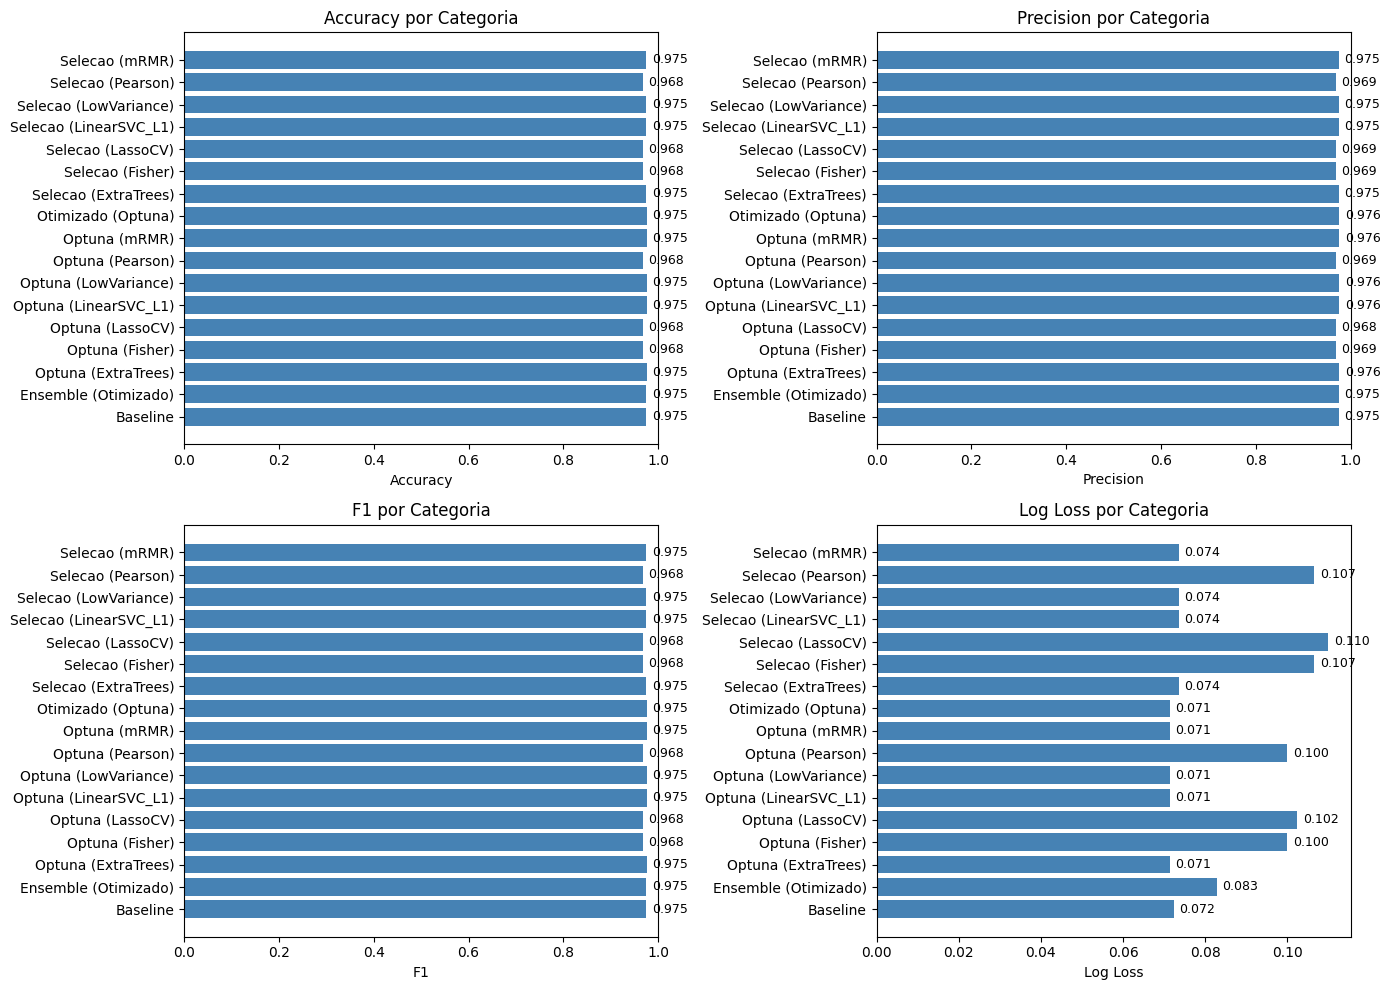

In [37]:
# Visualizacao comparativa final
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'f1', 'log_loss']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    if metric == 'log_loss':
        category_best = final_results.loc[final_results.groupby('categoria')[metric].idxmin()]
    else:
        category_best = final_results.loc[final_results.groupby('categoria')[metric].idxmax()]
    bars = ax.barh(category_best['categoria'], category_best[metric], color='steelblue')
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_title(f"{metric.replace('_', ' ').title()} por Categoria")
    if metric != 'log_loss':
        ax.set_xlim(0, 1)
    labels = [f'{val:.3f}' if np.isfinite(val) else 'N/A' for val in category_best[metric].values]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9)
plt.tight_layout()
plt.savefig('../reports/reports_ensemble_v2/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# Identificar o melhor modelo geral
best_model = final_results.iloc[0]
print("\n" + "=" * 80)
print("MELHOR MODELO IDENTIFICADO")
print("=" * 80)
print(f"Categoria: {best_model['categoria']}")
print(f"Modelo: {best_model['modelo']}")
print("\nMetricas:")
print(f"  Acuracia:  {best_model['accuracy']:.4f}")
print(f"  Precisao:  {best_model['precision']:.4f}")
print(f"  F1 Score:  {best_model['f1']:.4f}")
print(f"  Log Loss:  {best_model['log_loss']:.4f}")
print("\n" + "=" * 80)
print("RESUMO DAS ETAPAS")
print("=" * 80)
print("1. Limpeza e engenharia de features")
print(f"2. Baseline: {len(baseline_models)} modelos avaliados")
print(f"3. Selecao: {len(selectors)} metodos de selecao aplicados")
print("4. Ensemble: Soft Voting + Averaging")
print(f"5. Otimizacao: {N_TRIALS} trials por modelo com Optuna")



MELHOR MODELO IDENTIFICADO
Categoria: Otimizado (Optuna)
Modelo: GradientBoosting (Optuna)

Metricas:
  Acuracia:  0.9754
  Precisao:  0.9757
  F1 Score:  0.9754
  Log Loss:  0.0714

RESUMO DAS ETAPAS
1. Limpeza e engenharia de features
2. Baseline: 6 modelos avaliados
3. Selecao: 7 metodos de selecao aplicados
4. Ensemble: Soft Voting + Averaging
5. Otimizacao: 11 trials por modelo com Optuna


In [39]:
# Salvar modelos otimizados e metadados
import joblib
models_refactored_dir = Path('../models/models_ensemble_v2/base')
models_refactored_dir.mkdir(parents=True, exist_ok=True)
for model_name, model in optuna_trained_models.items():
    joblib.dump(model, models_refactored_dir / f'best_{model_name.lower()}_model.pkl')
joblib.dump(scaler, models_refactored_dir / 'scaler.pkl')
with open(models_refactored_dir / 'model_info.json', 'w') as f:
    json.dump({
        'consensus_features': consensus_features,
        'selected_features_by_method': selected_features_dict,
        'optuna_best_params': {k: v.best_params for k, v in optuna_studies.items()},
        'optuna_by_selector_best_params': optuna_by_selector_best_params if 'optuna_by_selector_best_params' in globals() else {},
        'best_model_global': {
            'categoria': best_model['categoria'],
            'modelo': best_model['modelo'],
            'accuracy': float(best_model['accuracy']),
            'precision': float(best_model['precision']),
            'f1': float(best_model['f1']),
            'log_loss': float(best_model['log_loss']),
        },
    }, f, indent=2)
print('OK: modelos e metadados salvos em models/models_refactored/')


OK: modelos e metadados salvos em models/models_refactored/


## 12. Relatório Detalhado em Markdown

In [40]:
%pip install tabulate
from tabulate import tabulate
# Consolidar e salvar tempos antes de gerar o relatorio
if timing_records:
    timing_df = pd.DataFrame(timing_records).copy()
else:
    timing_df = pd.DataFrame(columns=list(TIMING_DEFAULTS.keys()))
for col in ['tempo_fit_sec', 'tempo_predict_sec', 'tempo_proba_sec', 'tempo_joblib_dump_sec', 'tempo_otimizacao_sec', 'tempo_total_sec', 'n_features', 'n_trials', 'n_cv_folds']:
    if col in timing_df.columns:
        timing_df[col] = pd.to_numeric(timing_df[col], errors='coerce')
timing_df.to_csv('../reports/reports_ensemble_v2/timing_results.csv', index=False)
if not timing_df.empty:
    timing_stage_summary = (
        timing_df.groupby('stage', dropna=False)
        .agg(
            n_registros=('stage', 'size'),
            tempo_total_sec=('tempo_total_sec', 'sum'),
            tempo_medio_sec=('tempo_total_sec', 'mean'),
            tempo_min_sec=('tempo_total_sec', 'min'),
            tempo_max_sec=('tempo_total_sec', 'max'),
        )
        .reset_index()
        .sort_values('tempo_total_sec', ascending=False)
    )
    timing_model_summary = (
        timing_df[timing_df['modelo'].notna()]
        .groupby('modelo', dropna=False)
        .agg(
            n_registros=('modelo', 'size'),
            tempo_total_sec=('tempo_total_sec', 'sum'),
            tempo_medio_sec=('tempo_total_sec', 'mean'),
            tempo_min_sec=('tempo_total_sec', 'min'),
            tempo_max_sec=('tempo_total_sec', 'max'),
        )
        .reset_index()
        .sort_values('tempo_total_sec', ascending=False)
    )
    timing_selector_summary = (
        timing_df[timing_df['seletor'].notna()]
        .groupby('seletor', dropna=False)
        .agg(
            n_registros=('seletor', 'size'),
            n_features=('n_features', 'max'),
            tempo_total_sec=('tempo_total_sec', 'sum'),
            tempo_medio_sec=('tempo_total_sec', 'mean'),
            tempo_min_sec=('tempo_total_sec', 'min'),
            tempo_max_sec=('tempo_total_sec', 'max'),
        )
        .reset_index()
        .sort_values('tempo_total_sec', ascending=False)
    )
else:
    timing_stage_summary = pd.DataFrame(columns=['stage', 'n_registros', 'tempo_total_sec', 'tempo_medio_sec', 'tempo_min_sec', 'tempo_max_sec'])
    timing_model_summary = pd.DataFrame(columns=['modelo', 'n_registros', 'tempo_total_sec', 'tempo_medio_sec', 'tempo_min_sec', 'tempo_max_sec'])
    timing_selector_summary = pd.DataFrame(columns=['seletor', 'n_registros', 'n_features', 'tempo_total_sec', 'tempo_medio_sec', 'tempo_min_sec', 'tempo_max_sec'])
timing_stage_summary.to_csv('../reports/reports_ensemble_v2/timing_summary_by_stage.csv', index=False)
timing_model_summary.to_csv('../reports/reports_ensemble_v2/timing_summary_by_model.csv', index=False)
timing_selector_summary.to_csv('../reports/reports_ensemble_v2/timing_summary_by_selector.csv', index=False)
# Gerar relatorio markdown detalhado (versao padronizada)
report_lines = []
report_lines.append('# Relatorio de Analise: Deteccao de Ataques DoS em MQTT')
report_lines.append('')
report_lines.append(f"**Data:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
report_lines.append('**Modelos avaliados:** LDA, QDA, GaussianNB, DecisionTree, RandomForest, GradientBoosting')
report_lines.append('')
report_lines.append('## 1. Resultado Principal')
report_lines.append(f"- Melhor modelo global: {best_model['modelo']} ({best_model['categoria']})")
report_lines.append(f"- Acuracia: {best_model['accuracy']:.4f}")
report_lines.append(f"- Precisao: {best_model['precision']:.4f}")
report_lines.append(f"- F1 Score: {best_model['f1']:.4f}")
report_lines.append(f"- Log Loss: {best_model['log_loss']:.4f}")
report_lines.append('')
report_lines.append('## 2. Metricas Obrigatorias por Etapa')
report_lines.append('As quatro metricas obrigatorias (acuracia, precisao, f1 e log_loss) foram calculadas em baseline, selecao de features, ensemble e Optuna (global e por seletor).')
report_lines.append('')
report_lines.append('### Baseline')
report_lines.append(baseline_df.to_markdown(index=False))
report_lines.append('')
report_lines.append('### Selecao de Features - Melhor Modelo por Seletor')
report_lines.append(best_by_selector[['seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1', 'log_loss']].to_markdown(index=False))
report_lines.append('')
report_lines.append('### Ensemble')
report_lines.append(ensemble_comparison.to_markdown(index=False))
report_lines.append('')
report_lines.append('### Optuna Global')
report_lines.append(optuna_df[['modelo', 'accuracy', 'precision', 'f1', 'log_loss']].to_markdown(index=False))
report_lines.append('')
report_lines.append('### Optuna por Seletor - Melhor Modelo por Seletor')
if 'best_optuna_by_selector_df' in globals() and not best_optuna_by_selector_df.empty:
    report_lines.append(
        best_optuna_by_selector_df[
            ['seletor', 'modelo', 'n_features', 'accuracy', 'precision', 'f1', 'log_loss']
        ].to_markdown(index=False)
    )
else:
    report_lines.append('Nenhum resultado de Optuna por seletor disponivel.')
report_lines.append('')
report_lines.append('### Comparacao Sem Optuna vs Com Optuna por Seletor')
if 'optuna_by_selector_comparison' in globals() and not optuna_by_selector_comparison.empty:
    report_lines.append(
        optuna_by_selector_comparison[
            [
                'seletor',
                'modelo_sem_optuna', 'f1_sem_optuna', 'log_loss_sem_optuna',
                'modelo_com_optuna', 'f1_com_optuna', 'log_loss_com_optuna', 'delta_f1',
            ]
        ].to_markdown(index=False)
    )
else:
    report_lines.append('Comparacao por seletor indisponivel.')
report_lines.append('')
report_lines.append('## 3. Tempos de Execucao')
report_lines.append('Os tempos foram medidos com `time.perf_counter()` e registrados em segundos. Em linhas onde a medida nao se aplica, o valor fica como `NaN`.')
report_lines.append('')
report_lines.append('### 3.1 Resumo Por Etapa')
if not timing_stage_summary.empty:
    report_lines.append(timing_stage_summary.to_markdown(index=False))
else:
    report_lines.append('Sem dados de tempo registrados.')
report_lines.append('')
report_lines.append('### 3.2 Resumo Por Modelo')
if not timing_model_summary.empty:
    report_lines.append(timing_model_summary.to_markdown(index=False))
else:
    report_lines.append('Sem dados de tempo por modelo registrados.')
report_lines.append('')
report_lines.append('### 3.3 Resumo Por Seletor')
if not timing_selector_summary.empty:
    report_lines.append(timing_selector_summary.to_markdown(index=False))
else:
    report_lines.append('Sem dados de tempo por seletor registrados.')
report_lines.append('')
report_lines.append('### 3.4 Etapas Mais Custosas')
if not timing_stage_summary.empty:
    top_costly = timing_stage_summary.sort_values('tempo_total_sec', ascending=False).head(5)
    report_lines.append(top_costly[['stage', 'tempo_total_sec', 'tempo_medio_sec']].to_markdown(index=False))
else:
    report_lines.append('Sem dados para identificar etapas mais custosas.')
report_lines.append('')
report_lines.append('## 4. Analise de Falsos Positivos e Falsos Negativos')
report_lines.append('Para cada seletor de caracteristicas, foram geradas matrizes de confusao para todos os modelos e tambem para o melhor modelo do seletor.')
report_lines.append('')
report_lines.append('### 4.1 Melhor Modelo por Seletor - FP/FN por Classe')
for selector_name, payload in best_confusion_matrix_by_selector.items():
    cm = np.array(payload['confusion_matrix'])
    fp = (cm.sum(axis=0) - np.diag(cm)).tolist()
    fn = (cm.sum(axis=1) - np.diag(cm)).tolist()
    report_lines.append(f"- {selector_name}: modelo={payload['modelo']}, F1={payload['f1']:.4f}, FP={fp}, FN={fn}")
report_lines.append('')
report_lines.append('### 4.2 Matrizes de Confusao por Seletor')
for selector_name, models_map in confusion_matrices_by_selector.items():
    report_lines.append(f"#### Seletor: {selector_name}")
    for model_name, cm_list in models_map.items():
        cm = np.array(cm_list)
        fp = (cm.sum(axis=0) - np.diag(cm)).tolist()
        fn = (cm.sum(axis=1) - np.diag(cm)).tolist()
        report_lines.append(f"- {model_name}: FP={fp}, FN={fn}, CM={cm.tolist()}")
    report_lines.append('')
report_lines.append('## 5. Artefatos Gerados')
report_lines.append('- reports_refactored/baseline_results.csv')
report_lines.append('- reports_refactored/baseline_timing_results.csv')
report_lines.append('- reports_refactored/selection_results.csv')
report_lines.append('- reports_refactored/selection_timing_results.csv')
report_lines.append('- reports_refactored/selection_selector_timing_results.csv')
report_lines.append('- reports_refactored/best_model_by_selector.csv')
report_lines.append('- reports_refactored/ensemble_results.csv')
report_lines.append('- reports_refactored/optuna_results.csv')
report_lines.append('- reports_refactored/optuna_by_selector_results.csv')
report_lines.append('- reports_refactored/best_optuna_model_by_selector.csv')
report_lines.append('- reports_refactored/optuna_by_selector_comparison_cenario1_constant.csv')
report_lines.append('- reports_refactored/optuna_by_selector_best_params.json')
report_lines.append('- reports_refactored/optuna_by_selector_confusion_matrices.json')
report_lines.append('- reports_refactored/timing_results.csv')
report_lines.append('- reports_refactored/timing_summary_by_stage.csv')
report_lines.append('- reports_refactored/timing_summary_by_model.csv')
report_lines.append('- reports_refactored/timing_summary_by_selector.csv')
report_lines.append('- reports_refactored/final_results_all_models.csv')
report_lines.append('- reports_refactored/confusion_matrices_by_selector.json')
report_lines.append('- reports_refactored/best_confusion_matrix_by_selector.json')
report_lines.append('- reports_refactored/optuna_confusion_matrices.json')
report_lines.append('- reports_refactored/RELATORIO_FINAL.md')
report_lines.append('- models/models_optuna/*.pkl')
report_lines.append('- models/models_refactored/*.pkl')
report_lines.append('')
report = '\n'.join(report_lines)
with open('../reports/reports_ensemble_v2/RELATORIO_FINAL.md', 'w') as f:
    f.write(report)
print('OK: relatorio detalhado salvo em reports_refactored/RELATORIO_FINAL.md')
print(f'Tamanho do relatorio: {len(report)} caracteres')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
OK: relatorio detalhado salvo em reports_refactored/RELATORIO_FINAL.md
Tamanho do relatorio: 15270 caracteres


---
## Fim do Pipeline

Todos os artefatos foram gerados nas pastas refatoradas.

Para executar novamente, reinicie o kernel e execute todas as células.